# Aged Mouse Analysis
Dataset: Takasugi et al., Nature 2024 

Last Updated: 06-18-2026

# Directories, Dependencies, Helper Functions, & Data Pre-processing

In [494]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg


print("packages have been successfully read in!")

packages have been successfully read in!


In [495]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR     = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Takasugi_2024/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
MQ_DIR          = PROJ_DIR + 'frag_output/Takasugi_2024/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + '/Supplementary_Tables/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)

## Define dataset/TMT set folders 
#S1 AORTA
aorta_proj_dir      = OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_mq            = MQ_DIR + 'Aorta/aorta_1/'

#S2 BRAIN 
brain_proj_dir      = OUTDIR + 'Brain/'
brain_aa_subs_dir   = INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_mq            = MQ_DIR + 'Brain/brain_1/'

#S3 HEART
heart_proj_dir      = OUTDIR + 'Heart/'
heart_aa_subs_dir   = INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_mq            = MQ_DIR + 'Heart/heart_1/'

#S4 KIDNEY
kidney_proj_dir      = OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_mq            = MQ_DIR + 'Kidney/kidney_1/'

#S5 LIVER
liver_proj_dir      = OUTDIR + 'Liver/'
liver_aa_subs_dir   = INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_mq            = MQ_DIR + 'Liver/liver_1/'

#S6 LUNG
lung_proj_dir      = OUTDIR + 'Lung/'
lung_aa_subs_dir   = INDIR + 'Lung/'
lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
lung_mq            = MQ_DIR + 'Lung/lung_1/'

#S7 MUSCLE
muscle_proj_dir      = OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_mq            = MQ_DIR + 'Muscle/muscle_1/'

#S8 SKIN
skin_proj_dir      = OUTDIR + 'Skin/'
skin_aa_subs_dir   = INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_mq            = MQ_DIR + 'Skin/skin_1/'

#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map]
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir]
mq_dir_list = [aorta_mq, brain_mq, heart_mq, kidney_mq, liver_mq, lung_mq, muscle_mq, skin_mq]


print("directories loaded successfully!")

loading directories...


directories loaded successfully!


In [496]:
# Read in data generated from dependencies code
# if dependencies have not been generated, go back and generate in Analysis_Dependencies_ipynb

pos_prob_df = pd.read_csv(DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
print(pos_prob_df)
frag_dict = pickle.load(open(DEPDIR+'Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
print(frag_dict)

SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
#SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
# print(SAAP_quant_df)
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

                              SAAP                             BP       AAS  \
0                         PATVSLPR                       VATVSLPR    V to P   
1                         PFLENVIR                       VFLENVIR    V to P   
2                      PGDLGVDLTSK                    AGDLGVDLTSK    A to P   
3                        LPGGTTPGK                      LVGGTTPGK    V to P   
4                        LEQEITTYR                      LEQEIATYR    A to T   
..                             ...                            ...       ...   
156   ETTWHGQGQDQGQGPSQESAAEQGAVEK   ETPWHGQGQDQGQGPSQESAAEQGAVEK    P to T   
157  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ    P to T   
158        DNLTLWNSDTQGDEAEAGEGGEN        DNLTLWTSDTQGDEAEAGEGGEN    T to N   
159            DSTYSMSSLLTLTKDEYER            DSTYSMSSTLTLTKDEYER  T to I/L   
160            LYTWGVVEVENPEHNDFLK            LYPWGVVEVENPEHNDFLK    P to T   

     AAS index  Positional probability  charge TMT 

In [497]:
# Save as Supplemental_Data_1.SAAP_precursor_reporter_quant_aging.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_1.SAAP_precursor_reporter_quant_aging.xlsx',sheet_name='Users',index=True)

## Data Pre-processing

### a. Assess data completeness

In [498]:
# Assess data completeness of SAAPs in SAAP_quant_df 
print(f'{len(SAAP_quant_df):,} total SAAP observations in original dataset')
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% original dataset completeness')

# Option to replace read-in SAAP_quant_df with SAAP_quant_df that has 100% data completeness
# SAAP_quant_df = SAAP_quant_complete_df 

25,424 total SAAP observations in original dataset
22,658 fully complete SAAP observations retained
89.12% original dataset completeness


  Dataset  Completeness
0   Aorta     96.827864
1   Brain     96.333388
2   Heart     97.114460
3  Kidney     97.116325
4   Liver     96.075337
5    Lung     97.716293
6  Muscle     97.733879
7    Skin     97.478434


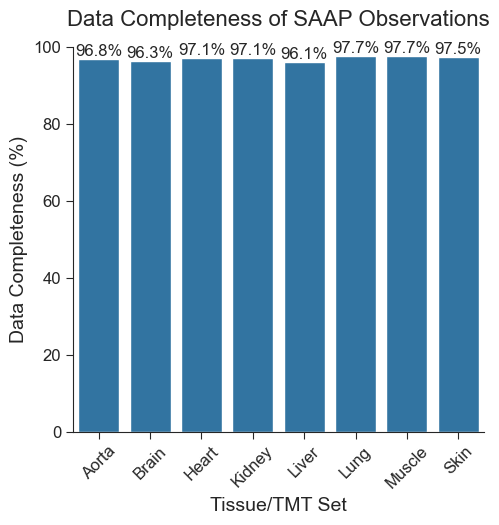

In [499]:
# Plot data completeness per tissue/TMT set 
comp_cols=['Positional_probability','SAAP_PEP','BP_PEP','MTP_PrecInt','BP_PrecInt','Prec_RAAS','MTP_ReportInt','BP_ReportInt','Reporter_RAAS','BP_ReportInt_Norm','MTP_ReportInt_Norm']

comp_df = SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df = comp_df[comp_df['Dataset']==ds]
    total_val = len(ds_df)*len(comp_cols)
    nonmissing_val = sum(ds_df[c].notna().sum() for c in comp_cols)
    completeness = 100*(nonmissing_val/total_val)
    plot_rows.append({'Dataset': ds, 'Completeness': completeness})

plot_df = pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
print(plot_df)

fig,ax = plt.subplots(figsize=(5.3,5))
sns.set_style('ticks')
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color='#1f78b4',ax=ax)
ax.tick_params('both',labelsize=12,length=5)
ax.tick_params(axis='x',rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('Data Completeness (%)',fontsize=14)
plt.ylim(0,100) 
plt.title('Data Completeness of SAAP Observations',fontsize=16,pad=15)
sns.despine()

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',label_type='edge',fontsize=12)

plt.savefig(PLOT_DIR + 'SAAP_data_completeness.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR + 'SAAP_data_completeness.png',dpi=600,bbox_inches='tight')

### b. Remove immunoglobulins and trypsin mapping SAAPs 

In [500]:
"""
Assign each SAAP a source protein/gene from FragPipe psm.tsv & drop Ig/trypsin/unresolved

1. Each SAAP (MTP_seq) is a substituted peptide that exists only in the synthetic search
space, so its parent protein is read off the BASE peptide (BP_seq) — the reference
sequence matched in that SAAP's OWN tissue (Dataset) FragPipe psm.tsv.
2. Gene symbols and protein descriptions come directly from psm.tsv columns
('Gene', 'Protein Description'), keyed by canonical accession ('Protein ID').
3. SAAPs are dropped if their base peptide maps to an immunoglobulin chain, to trypsin,
or to no NAMED protein (no gene and no description), before any downstream QC.

NOTE: resolution is keyed by (Dataset, BP_seq) so a base peptide observed in multiple
tissues is matched only against its own tissue's psm.tsv.
"""

# keep only the lead (razor) accession per base peptide. In FragPipe psm.tsv the
# 'Protein ID' column IS already the lead protein, so this is the default behavior;
# the rest of the protein group lives in 'Mapped Proteins'.
LEAD_ACCESSION_ONLY = True

def canon(acc):
    """Canonical accession: drop CON__ prefix and isoform (-2) suffix."""
    return acc.replace('CON__', '').split('-')[0]

# accession -> (gene, description) read directly from each plex's psm.tsv columns.
# psm.tsv resolves gene/description per PSM, so no FASTA-header parsing is needed.
acc_gene, acc_desc = {}, {}
for mq_dir in mq_dir_list:
    cols = ['Protein ID', 'Gene', 'Protein Description', 'Mapped Proteins', 'Mapped Genes']
    psm = pd.read_csv(mq_dir + 'psm.tsv', sep='\t', low_memory=False,
                      usecols=lambda c: c in cols)
    for acc, gene, desc in zip(psm['Protein ID'], psm.get('Gene', ''), psm.get('Protein Description', '')):
        a = canon(str(acc))
        if pd.notna(desc) and str(desc).strip():
            acc_desc.setdefault(a, str(desc).strip())
        if pd.notna(gene) and str(gene).strip():
            acc_gene.setdefault(a, str(gene).strip())
print(f'{len(acc_desc):,} reference proteins parsed from psm.tsv')

# (dataset, peptide sequence) -> FragPipe lead protein, indexed PER TISSUE so a base
# peptide shared across tissues resolves against its own tissue's psm.tsv.
# Also capture 'Mapped Proteins' so the full group is available when LEAD_ACCESSION_ONLY is False.
seq_to_proteins = {}
for dataset, mq_dir in zip(datasets, mq_dir_list):
    cols = ['Peptide', 'Protein', 'Mapped Proteins']
    psm = pd.read_csv(mq_dir + 'psm.tsv', sep='\t', low_memory=False,
                      usecols=lambda c: c in cols)
    for seq, prot, mapped in zip(psm['Peptide'], psm['Protein'].astype(str),
                                 psm.get('Mapped Proteins', pd.Series('')).astype(str)):
        if prot and prot != 'nan':
            # join lead + mapped into one ';'-style string, mirroring MaxQuant 'Proteins'
            full = prot if mapped in ('', 'nan') else prot + ';' + mapped.replace(', ', ';')
            seq_to_proteins.setdefault((dataset, seq), full)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(mq_dir_list)} psm.tsv files')

def proteins_to_accessions(protein_str):
    """Real UniProt accessions in a FragPipe protein string (drops synthetic MTP| entries).
    With LEAD_ACCESSION_ONLY, returns only the leading (first) accession in the group."""
    accs = []
    for tok in str(protein_str).split(';'):
        tok = tok.strip().replace('CON__', '')
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append(canon(m.group(1)))  # canonicalize to match psm.tsv-derived keys
    accs = list(dict.fromkeys(accs))  # unique, order-preserving
    return accs[:1] if LEAD_ACCESSION_ONLY else accs

# resolve each SAAP's base peptide to accessions within its own tissue
row_accs = [proteins_to_accessions(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'], SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].head(10).to_string())

# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexmaropakis/Projects/Project_BrainDecode/frag_output/Takasugi_2024/Aorta/aorta_1/psm.tsv'

8
0
468
          Category  Count
0  Immunoglobulins      8
1         Trypsins      0
2            SAAPs    468


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3776715020.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)


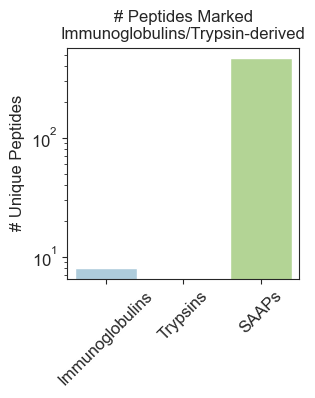

In [ ]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(3,3))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [429]:
# drop SAAPs that map to no NAMED protein (blank gene AND blank description), then drop the
# immunoglobulin and trypsin contaminants. This removes contaminant-only / unnamed hits.
n0 = len(SAAP_quant_df)
# unnamed = (SAAP_quant_df['Source_gene'] == '') & (SAAP_quant_df['Source_protein'] == '')
unnamed = (SAAP_quant_df['Source_gene'] == '')
print(f"\n{unnamed.sum():,} SAAP observations map to no named protein — dropped")
drop_mask = unnamed | (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)
print(f'{n0:,} -> {len(SAAP_quant_df):,} SAAP observations retained '
      f'({drop_mask.sum():,} dropped: unnamed + immunoglobulin + trypsin)')


832 SAAP observations map to no named protein — dropped
25,424 -> 24,448 SAAP observations retained (976 dropped: unnamed + immunoglobulin + trypsin)


# 1. SAAP Detection & QC

## 1a Dataset Metrics

In [430]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 600x500 with 0 Axes>

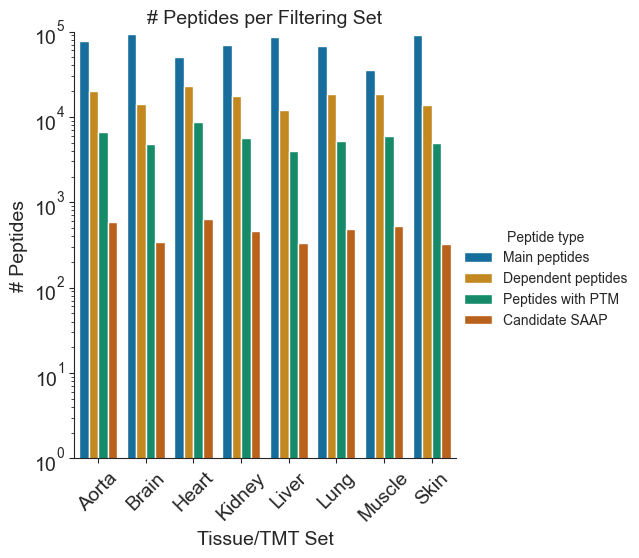

In [431]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(6,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1)

ax.set(yscale='log', ylim=(1, 1e5))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [432]:
#filter_dict = pickle.load(open(outdir+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))
all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set', 'Dataset', 'Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
        
print(sum_dict) # these values are used in 1a

{'Main peptides': np.int64(571297), 'DP': np.int64(138057), 'PTM': np.int64(46004), 'AAS': np.int64(3943), 'Non-homologous': np.int64(3942), 'High-confidence': np.int64(3703), 'Validated': np.int64(2058)}


### Percentage of candidate SAAPs validated through database search

In [433]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

Aorta
Brain
Heart
Kidney
Liver
Lung
Muscle
Skin


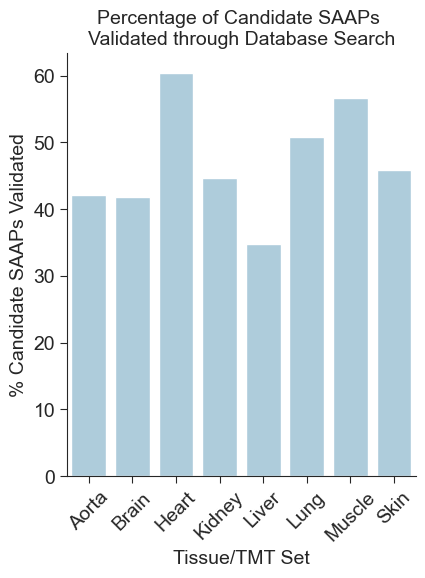

In [434]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='Paired')
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14)
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

## 1b Validation Metrics

### Retention time & predicted spectra validations (MSBooster)

In [ ]:
"""
Localization rescue of SAAPs using MSBooster spectral entropy and RT agreement.

A SAAP's positional probability is only high when the MS2 spectrum has the b/y ions
flanking the substituted residue. Low-abundance or poorly-fragmenting peptides often
lack those ions, so a real SAAP can score low purely from missing fragments. A hard
positional-probability cut therefore discards genuine SAAPs.

To recover them we use two orthogonal MSBooster scores from the *_edited.pin files:

  weighted_spectral_entropy : how well the observed spectrum matches the predicted
                              spectrum for the assigned SAAP (higher = better).
  delta_RT_loess            : difference between observed and predicted retention
                              time, loess-calibrated and already absolute
                              (lower = better). Orthogonal to spectral matching.

Both thresholds are calibrated against DECOYS. Each pin row has Label = 1 (target) or
-1 (decoy). We set each threshold to admit a chosen small fraction of decoys
(DECOY_ADMIT), giving every cutoff a known decoy-admission rate rather than an
arbitrary number.

Rule: keep a SAAP if it is confidently localized (positional probability >= cut),
OR if it is uncertainly localized but passes BOTH the entropy and RT thresholds.

Note: the entropy score is one-sided (it only checks the SAAP matches itself), so it
cannot reject an isobaric substitution like I<->L where the SAAP and base peptide give
the same spectrum. Those land at RAAS ~ 0; the check at the end reports how many
rescued SAAPs fall there.

Requires:
  - SAAP_quant_df with 'Positional_probability' and (per-SAAP, joined upstream)
    'spectral_entropy' and 'delta_RT' columns;
  - the *_edited.pin files, used here only to calibrate thresholds from decoys.
"""

POS_PROB_CUT = 0.9     # localization-confidence cut
DECOY_ADMIT  = 0.05    # fraction of decoys each threshold is allowed to admit (5%)

# ---- calibrate thresholds from decoys across all plex pins --------------------
# Pool every _edited.pin (all plexes), split by Label, and set:
#   entropy threshold = value admitting DECOY_ADMIT of decoys from the top (high=good)
#   RT threshold      = value admitting DECOY_ADMIT of decoys from the bottom (low=good)
ent_decoy, rt_decoy = [], []
for mq_dir in mq_dir_list:
    for f in glob(mq_dir + '*_edited.pin'):
        cols = ['Label', 'weighted_spectral_entropy', 'delta_RT_loess']
        d = pd.read_csv(f, sep='\t', usecols=cols, low_memory=False)
        dec = d[d['Label'] == -1]
        ent_decoy.append(dec['weighted_spectral_entropy'].values)
        rt_decoy.append(dec['delta_RT_loess'].values)
ent_decoy = np.concatenate(ent_decoy)
rt_decoy  = np.concatenate(rt_decoy)

ENTROPY_THRESHOLD = np.nanpercentile(ent_decoy, 100 * (1 - DECOY_ADMIT))  # high = good
RT_THRESHOLD      = np.nanpercentile(rt_decoy,  100 * DECOY_ADMIT)        # low  = good
print(f'Decoy-calibrated thresholds (admit {DECOY_ADMIT:.0%} of decoys):')
print(f'  weighted_spectral_entropy >= {ENTROPY_THRESHOLD:.4f}')
print(f'  delta_RT_loess            <= {RT_THRESHOLD:.4f}')

# ---- apply the rescue gate ----------------------------------------------------
pp  = SAAP_quant_df['Positional_probability']
ent = SAAP_quant_df['spectral_entropy']     # weighted_spectral_entropy, joined upstream
rt  = SAAP_quant_df['delta_RT']             # delta_RT_loess, joined upstream

pass_localization = pp >= POS_PROB_CUT
rescued = (pp < POS_PROB_CUT) & (ent >= ENTROPY_THRESHOLD) & (rt <= RT_THRESHOLD)

SAAP_quant_df['localization_pass'] = pass_localization
SAAP_quant_df['entropy_rescued']   = rescued
SAAP_quant_df['keep_localization'] = pass_localization | rescued

# ---- report what the rescue changed -------------------------------------------
n_total = len(SAAP_quant_df)
n_kept  = int(SAAP_quant_df['keep_localization'].sum())
print(f'passed positional prob >= {POS_PROB_CUT}: {int(pass_localization.sum()):,}')
print(f'rescued (entropy AND RT):         {int(rescued.sum()):,}')
print(f'total kept:                       {n_kept:,} of {n_total:,} ({n_kept/n_total:.1%})')
print(f'dropped:                          {n_total - n_kept:,}')

# ---- check whether rescued SAAPs pile up at RAAS ~ 0 (isobaric artifacts) ------
for col in ['Reporter_RAAS', 'Prec_RAAS']:
    if col in SAAP_quant_df.columns:
        r = pd.to_numeric(SAAP_quant_df.loc[rescued, col], errors='coerce').dropna()
        if len(r):
            print(f'rescued {col} within |RAAS|<0.15: {(r.abs() < 0.15).mean():.1%}')

# Apply filtering
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['keep_localization']].reset_index(drop=True)
print(f'filtered SAAP_quant_df: {len(SAAP_quant_df):,} rows retained')

Decoy-calibrated thresholds (admit 5% of decoys):
  weighted_spectral_entropy >= 0.9398
  delta_RT_loess            <= 2.3628
passed positional prob >= 0.9: 8,608
rescued (entropy AND RT):         4,464
total kept:                       13,072 of 24,448 (53.5%)
dropped:                          11,376
rescued Reporter_RAAS within |RAAS|<0.15: 7.2%
rescued Prec_RAAS within |RAAS|<0.15: 6.8%
filtered SAAP_quant_df: 13,072 rows retained


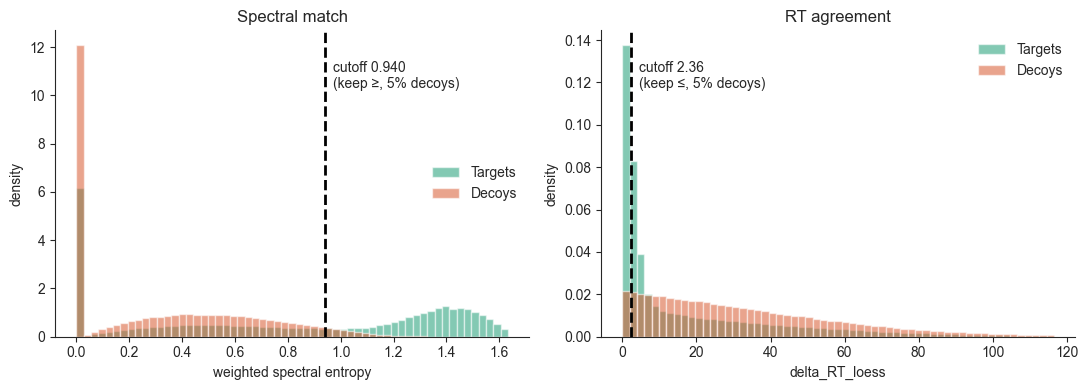

entropy >= 0.940: keeps 49.7% targets, 5.0% decoys
delta_RT <= 2.36:  keeps 31.2% targets, 5.0% decoys


In [436]:
"""
Visualize the decoy-calibrated rescue thresholds.

Pools all *_edited.pin rows across plexes, splits target (Label=1) vs decoy (Label=-1),
and plots the two rescue features with the cutoff that admits DECOY_ADMIT of decoys:

  weighted_spectral_entropy : keep if >= threshold (higher = better spectral match)
  delta_RT_loess            : keep if <= threshold (lower = better RT agreement)

The point of each panel: targets separate from decoys, and the cutoff is placed where
only DECOY_ADMIT (e.g. 5%) of decoys remain on the 'keep' side.
"""

DECOY_ADMIT = 0.05

# ---- pool target/decoy feature values across all plex pins ----
ent_t, ent_d, rt_t, rt_d = [], [], [], []
for mq_dir in mq_dir_list:
    for f in glob(mq_dir + '*_edited.pin'):
        d = pd.read_csv(f, sep='\t',
                        usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'],
                        low_memory=False)
        t   = d[d['Label'] == 1]
        dec = d[d['Label'] == -1]
        ent_t.append(t['weighted_spectral_entropy'].values)
        ent_d.append(dec['weighted_spectral_entropy'].values)
        rt_t.append(t['delta_RT_loess'].values)
        rt_d.append(dec['delta_RT_loess'].values)
ent_t = np.concatenate(ent_t); ent_d = np.concatenate(ent_d)
rt_t  = np.concatenate(rt_t);  rt_d  = np.concatenate(rt_d)

# ---- decoy-calibrated thresholds ----
ent_thr = np.nanpercentile(ent_d, 100 * (1 - DECOY_ADMIT))  # high = good
rt_thr  = np.nanpercentile(rt_d,  100 * DECOY_ADMIT)         # low  = good

# ---- plot ----
T_COLOR, D_COLOR = '#1D9E75', '#D85A30'   # target green, decoy coral
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# entropy panel
ax = axes[0]
bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
ax.hist(ent_t, bins=bins, density=True, color=T_COLOR, alpha=0.55, label='Targets')
ax.hist(ent_d, bins=bins, density=True, color=D_COLOR, alpha=0.55, label='Decoys')
ax.axvline(ent_thr, color='k', ls='--', lw=2)
ax.annotate(f'cutoff {ent_thr:.3f}\n(keep \u2265, {DECOY_ADMIT:.0%} decoys)',
            xy=(ent_thr, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel('weighted spectral entropy')
ax.set_ylabel('density')
ax.set_title('Spectral match')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# RT panel
ax = axes[1]
bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
ax.hist(rt_t, bins=bins, density=True, color=T_COLOR, alpha=0.55, label='Targets')
ax.hist(rt_d, bins=bins, density=True, color=D_COLOR, alpha=0.55, label='Decoys')
ax.axvline(rt_thr, color='k', ls='--', lw=2)
ax.annotate(f'cutoff {rt_thr:.2f}\n(keep \u2264, {DECOY_ADMIT:.0%} decoys)',
            xy=(rt_thr, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel('delta_RT_loess')
ax.set_ylabel('density')
ax.set_title('RT agreement')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'rescue_threshold_target_decoy.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'rescue_threshold_target_decoy.png', dpi=600, bbox_inches='tight')
plt.show()

# report keep-rates at these thresholds
print(f'entropy >= {ent_thr:.3f}: keeps {(ent_t>=ent_thr).mean():.1%} targets, {(ent_d>=ent_thr).mean():.1%} decoys')
print(f'delta_RT <= {rt_thr:.2f}:  keeps {(rt_t<=rt_thr).mean():.1%} targets, {(rt_d<=rt_thr).mean():.1%} decoys')

### Positional probability filtering

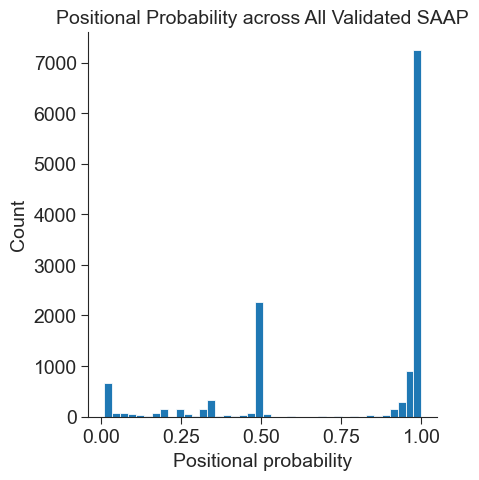

In [437]:
# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

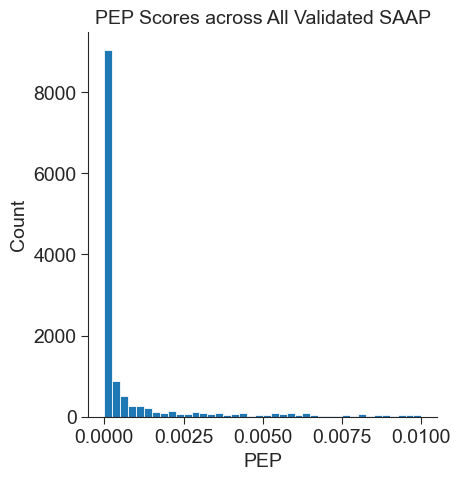

In [438]:
# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

In [439]:
# Save as Supplemental_Data_2.SAAP_precursor_reporter_quant_aging_highConfidence.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_2.SAAP_precursor_reporter_quant_aging_HighConfidence.xlsx',sheet_name='Users',index=True)
print(SAAP_quant_df['MTP_seq'].nunique())

645


### Fragment ion support at substitution site

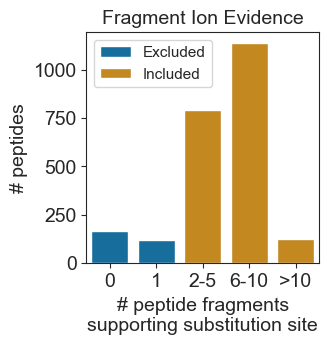

In [440]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = pd.read_excel(DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind')
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

### PEP scores and q values

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/1426888465.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/1426888465.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/1426888465.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/1426888465.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


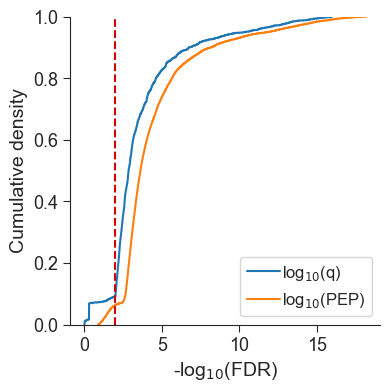

In [441]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.png',dpi=600, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2872710814.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2872710814.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2872710814.py:58: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = hi

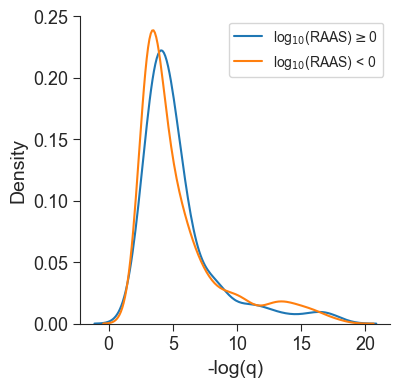

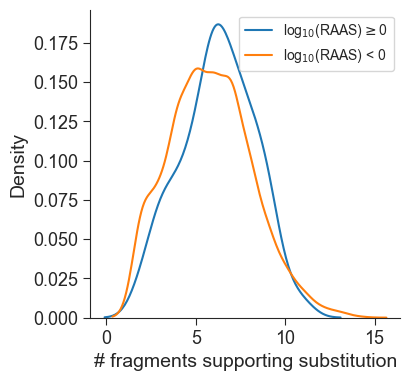

In [442]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log(q)', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.png', dpi=600, bbox_inches='tight')


# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.png',dpi=600, bbox_inches='tight')

### Mass errors for SAAPs and main peptides

In [443]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

Aorta S1 rows: 1600
    MTP_seq  Reporter_RAAS
0  PFLENVIR      -3.196934
1  PFLENVIR      -3.135212
2  PFLENVIR      -3.249404
3  PFLENVIR      -3.238023
4  PFLENVIR      -3.155241
High SAAP: ['SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'D

Kidney S4 rows: 1296
          MTP_seq  Reporter_RAAS
6016  TRLEQEITTYR      -0.653454
6017  TRLEQEITTYR      -0.587959
6018  TRLEQEITTYR      -0.831570
6019  TRLEQEITTYR      -0.688203
6020  TRLEQEITTYR      -0.669009
High SAAP: ['ETAHWKPPTWNDVDILK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'ESEAVEDQQK', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VTGQFTWSSLR', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDPNILYGPLHTK', 'VGNTWDP

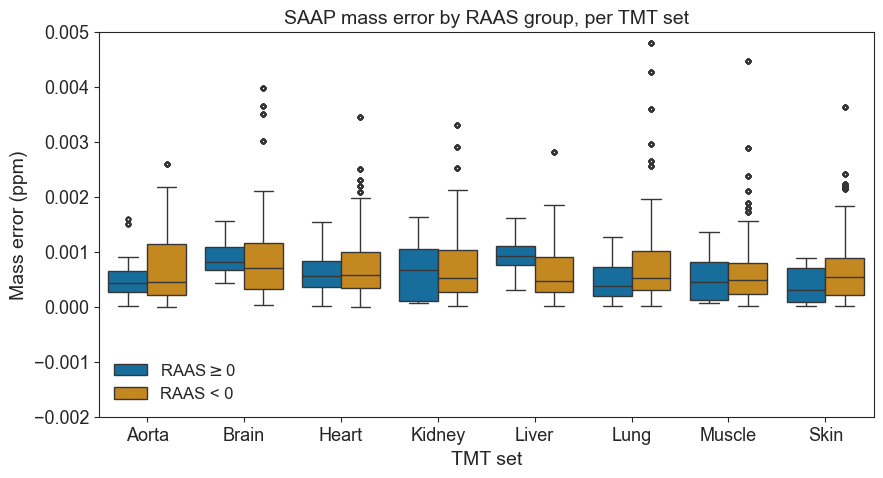

In [444]:
# mass error analysis
SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{ds} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[ds]['High RAAS mass error']  = mass_err_dict[ds]['High RAAS mass error'] + high_errs
            mass_err_dict[ds]['Low RAAS mass error']  = mass_err_dict[ds]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

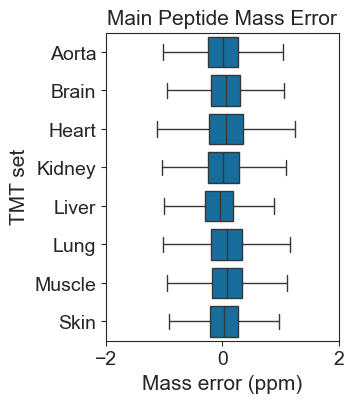

In [445]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[ds]['Main peptide mass error'] = mass_err_dict[ds]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

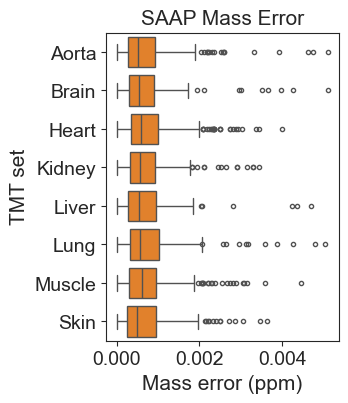

In [446]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[ds]['SAAP mass error'] = mass_err_dict[ds]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

### N SAAPs post-filtering/validation

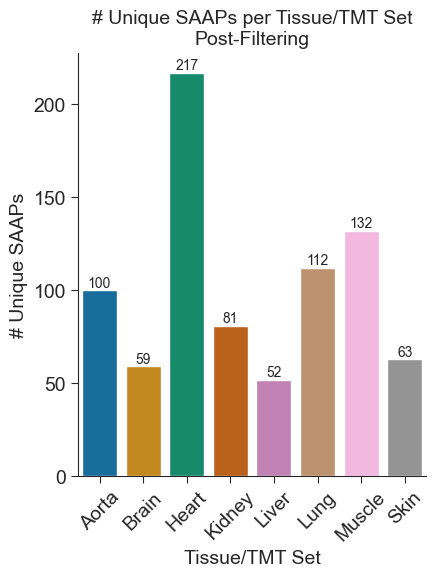

In [447]:
# N SAAPs per dataset post-filtering
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.png',dpi=600,bbox_inches='tight')

# 2. RAAS

## 2a Global Metrics

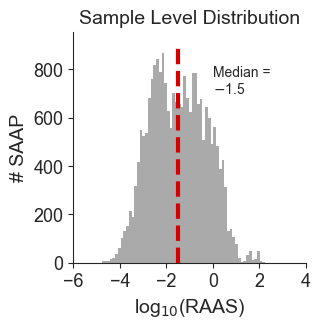

In [448]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=60, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

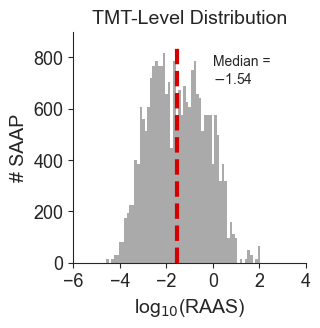

In [449]:
# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=60, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4])
ax.set_title(r'TMT-Level Distribution',fontsize=14)
sns.despine()

plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.png', dpi=600, bbox_inches='tight')

## 2b Precursor and Reporter RAAS Agreeability

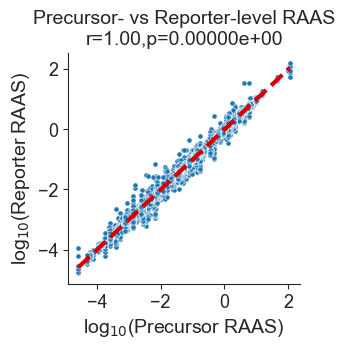

In [450]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.set_style('ticks')
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color=colors[0],edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

## 2c Tissue-level RAAS Distributions

In [451]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=30, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2702066803.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


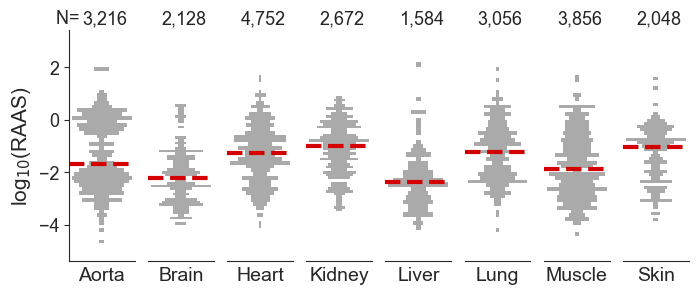

In [452]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Prec_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians)) # sort by median instead
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.png',dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3349579470.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


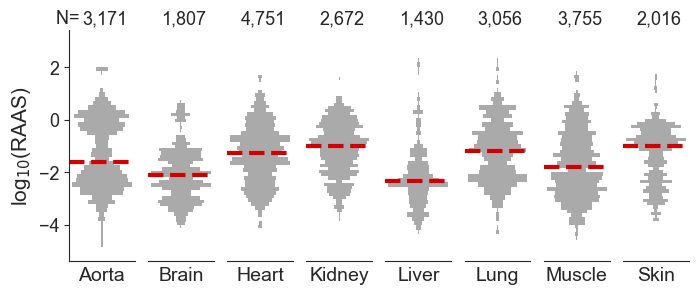

In [453]:
# sample/reporter ion level RAAS distributions for each dataset, code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/487779949.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


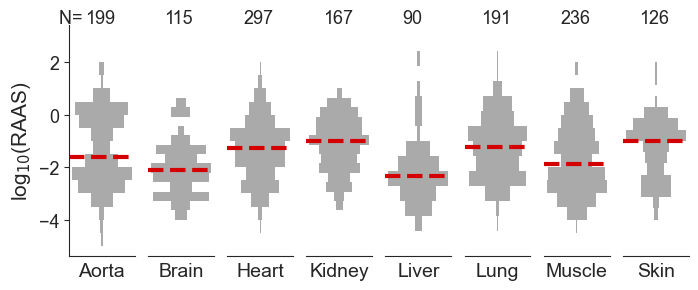

In [454]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

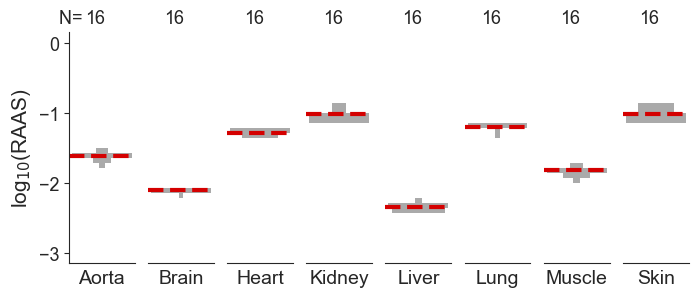

In [455]:
# Sample median RAAS distributions
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)
        
medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in sample_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

SAAPs in >= 6 tissues: 5


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2150870746.py:28: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


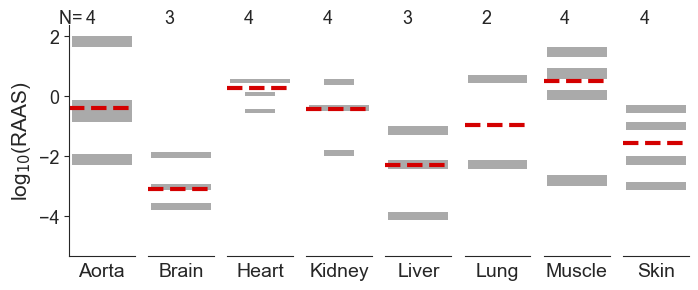

In [456]:
# Median RAAS distributions for SAAPs shared across all tissues, per dataset
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# SAAPs (MTP_seq) present in every dataset/tissue
saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
from collections import Counter

MIN_TISSUES = 6  # set to e.g. 2 for "≥2 tissues", or len(datasets) for strict

saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
counts = Counter()
for s in saap_set_list:
    counts.update(s)
shared_saap = {s for s,c in counts.items() if c >= MIN_TISSUES}
print('SAAPs in >= {} tissues: {}'.format(MIN_TISSUES, len(shared_saap)))

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3245370680.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


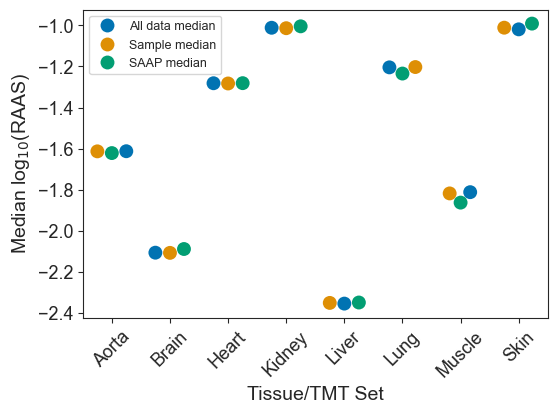

In [457]:
# Medians for all data, sample, and SAAP-level RAAS 
all_medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
all_medians.append(np.nanmedian(SAAP_quant_df_list[-1]['Reporter_RAAS'].values))

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)

sample_medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets))]
saap_medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets))]

plot_rows = []
plot_cols = ['Dataset', 'Median RAAS', 'Median type']
for m, median in enumerate(all_medians):
    plot_rows.append([datasets[m], median, 'All data median'])
for m, median in enumerate(sample_medians):
    plot_rows.append([datasets[m], median, 'Sample median'])
for m, median in enumerate(saap_medians):
    plot_rows.append([datasets[m], median, 'SAAP median'])
    
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)    

fig,ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plot_df, x='Dataset', y='Median RAAS', hue='Median type', s=10,
              palette='colorblind',order=tissue_order)
plt.legend(loc='upper left',title='', fontsize=9)
ax.tick_params('both', labelsize=13)
plt.xticks(rotation=45)
plt.ylabel('Median log$_{10}$(RAAS)', fontsize=14)
plt.xlabel('Tissue/TMT Set',fontsize=14)

plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.png', dpi=600, bbox_inches='tight')

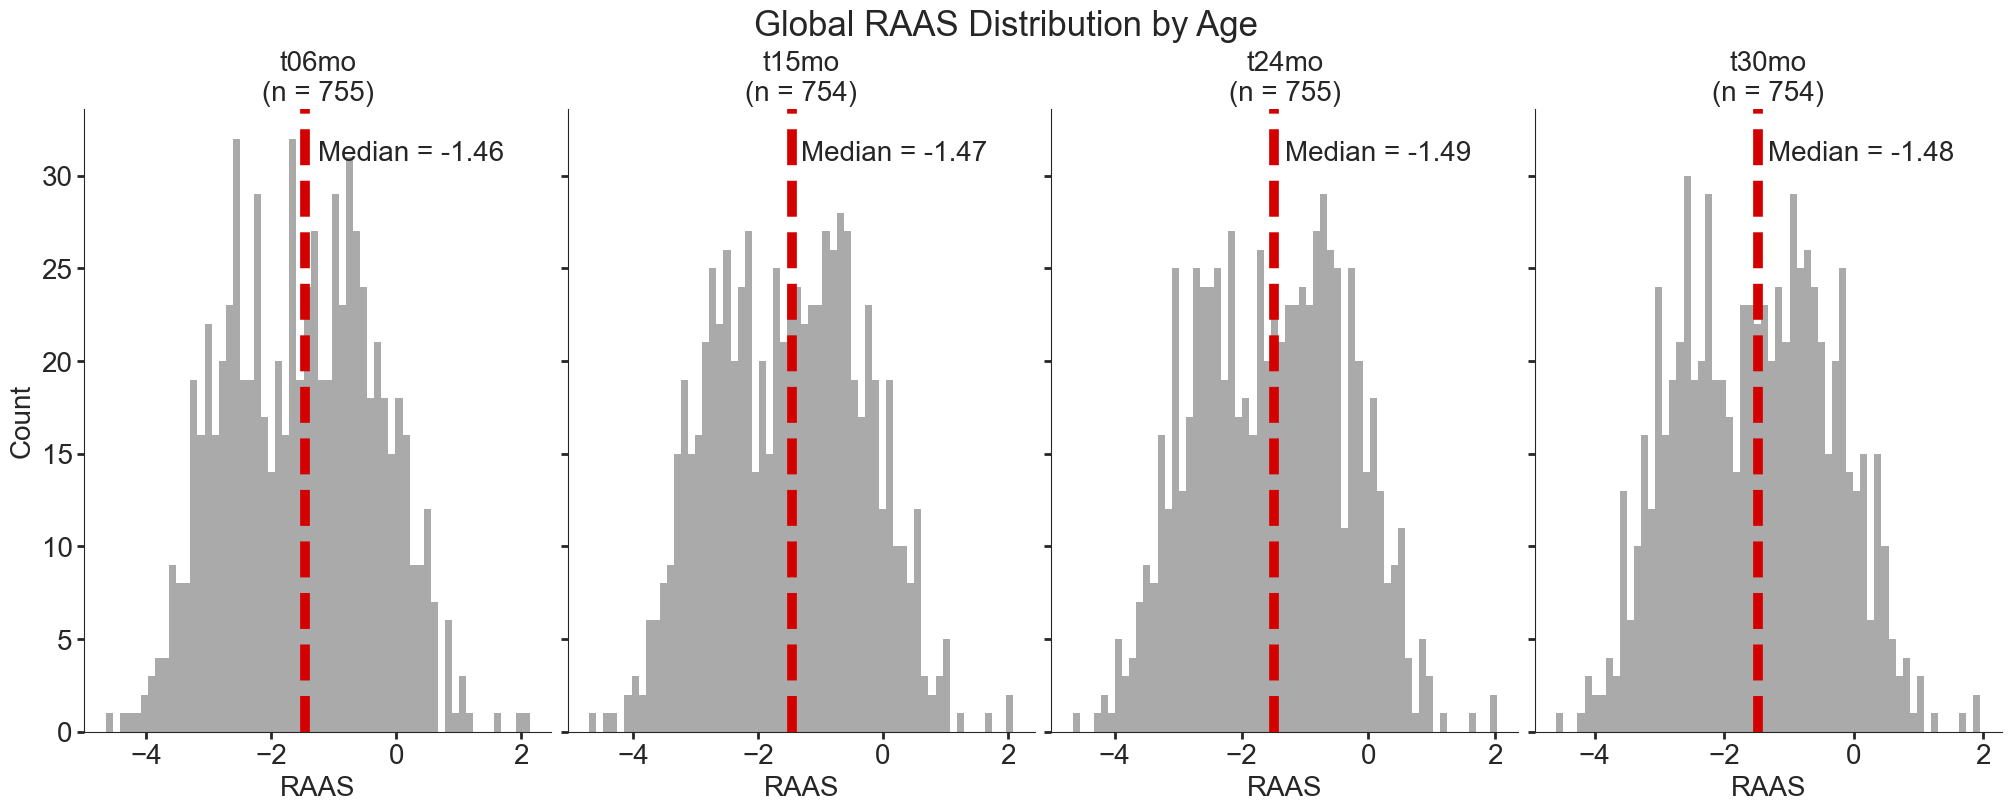

In [458]:
# sample level RAAS distribution by age
# one SAAP RAAS value is the median of its replicates 

age_df = SAAP_quant_df.copy()
age_df = age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = age_df['Sample Type'].unique()
num_ages = len(ages)

fig,axes = plt.subplots(1, num_ages, figsize=(5*num_ages, 8), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    ax = axes[i]
    subset = age_df[age_df['Sample Type'] == age]
    vals = subset['Reporter_RAAS'].values
    vals = vals[np.isfinite(vals)] 

    sns.histplot(vals, bins=60, kde=False, ax=ax,
                 color='#aaaaaa', edgecolor=None, linewidth=0,alpha=1)

    median = np.median(vals)
    ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

    n = len(vals)
    ax.set_title(f'{age}\n(n = {n})', fontsize=20)
    ax.tick_params(axis='both', labelsize=20, length=5, width=2)
    ax.set_xlabel('RAAS', fontsize=20)
    ax.set_ylabel('Count', fontsize=20)
    ax.grid(False)
    sns.despine()

    ax.text(0.5, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
            fontsize=20, verticalalignment='top')

plt.suptitle('Global RAAS Distribution by Age',fontsize=25)
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.png', dpi=600, bbox_inches='tight')

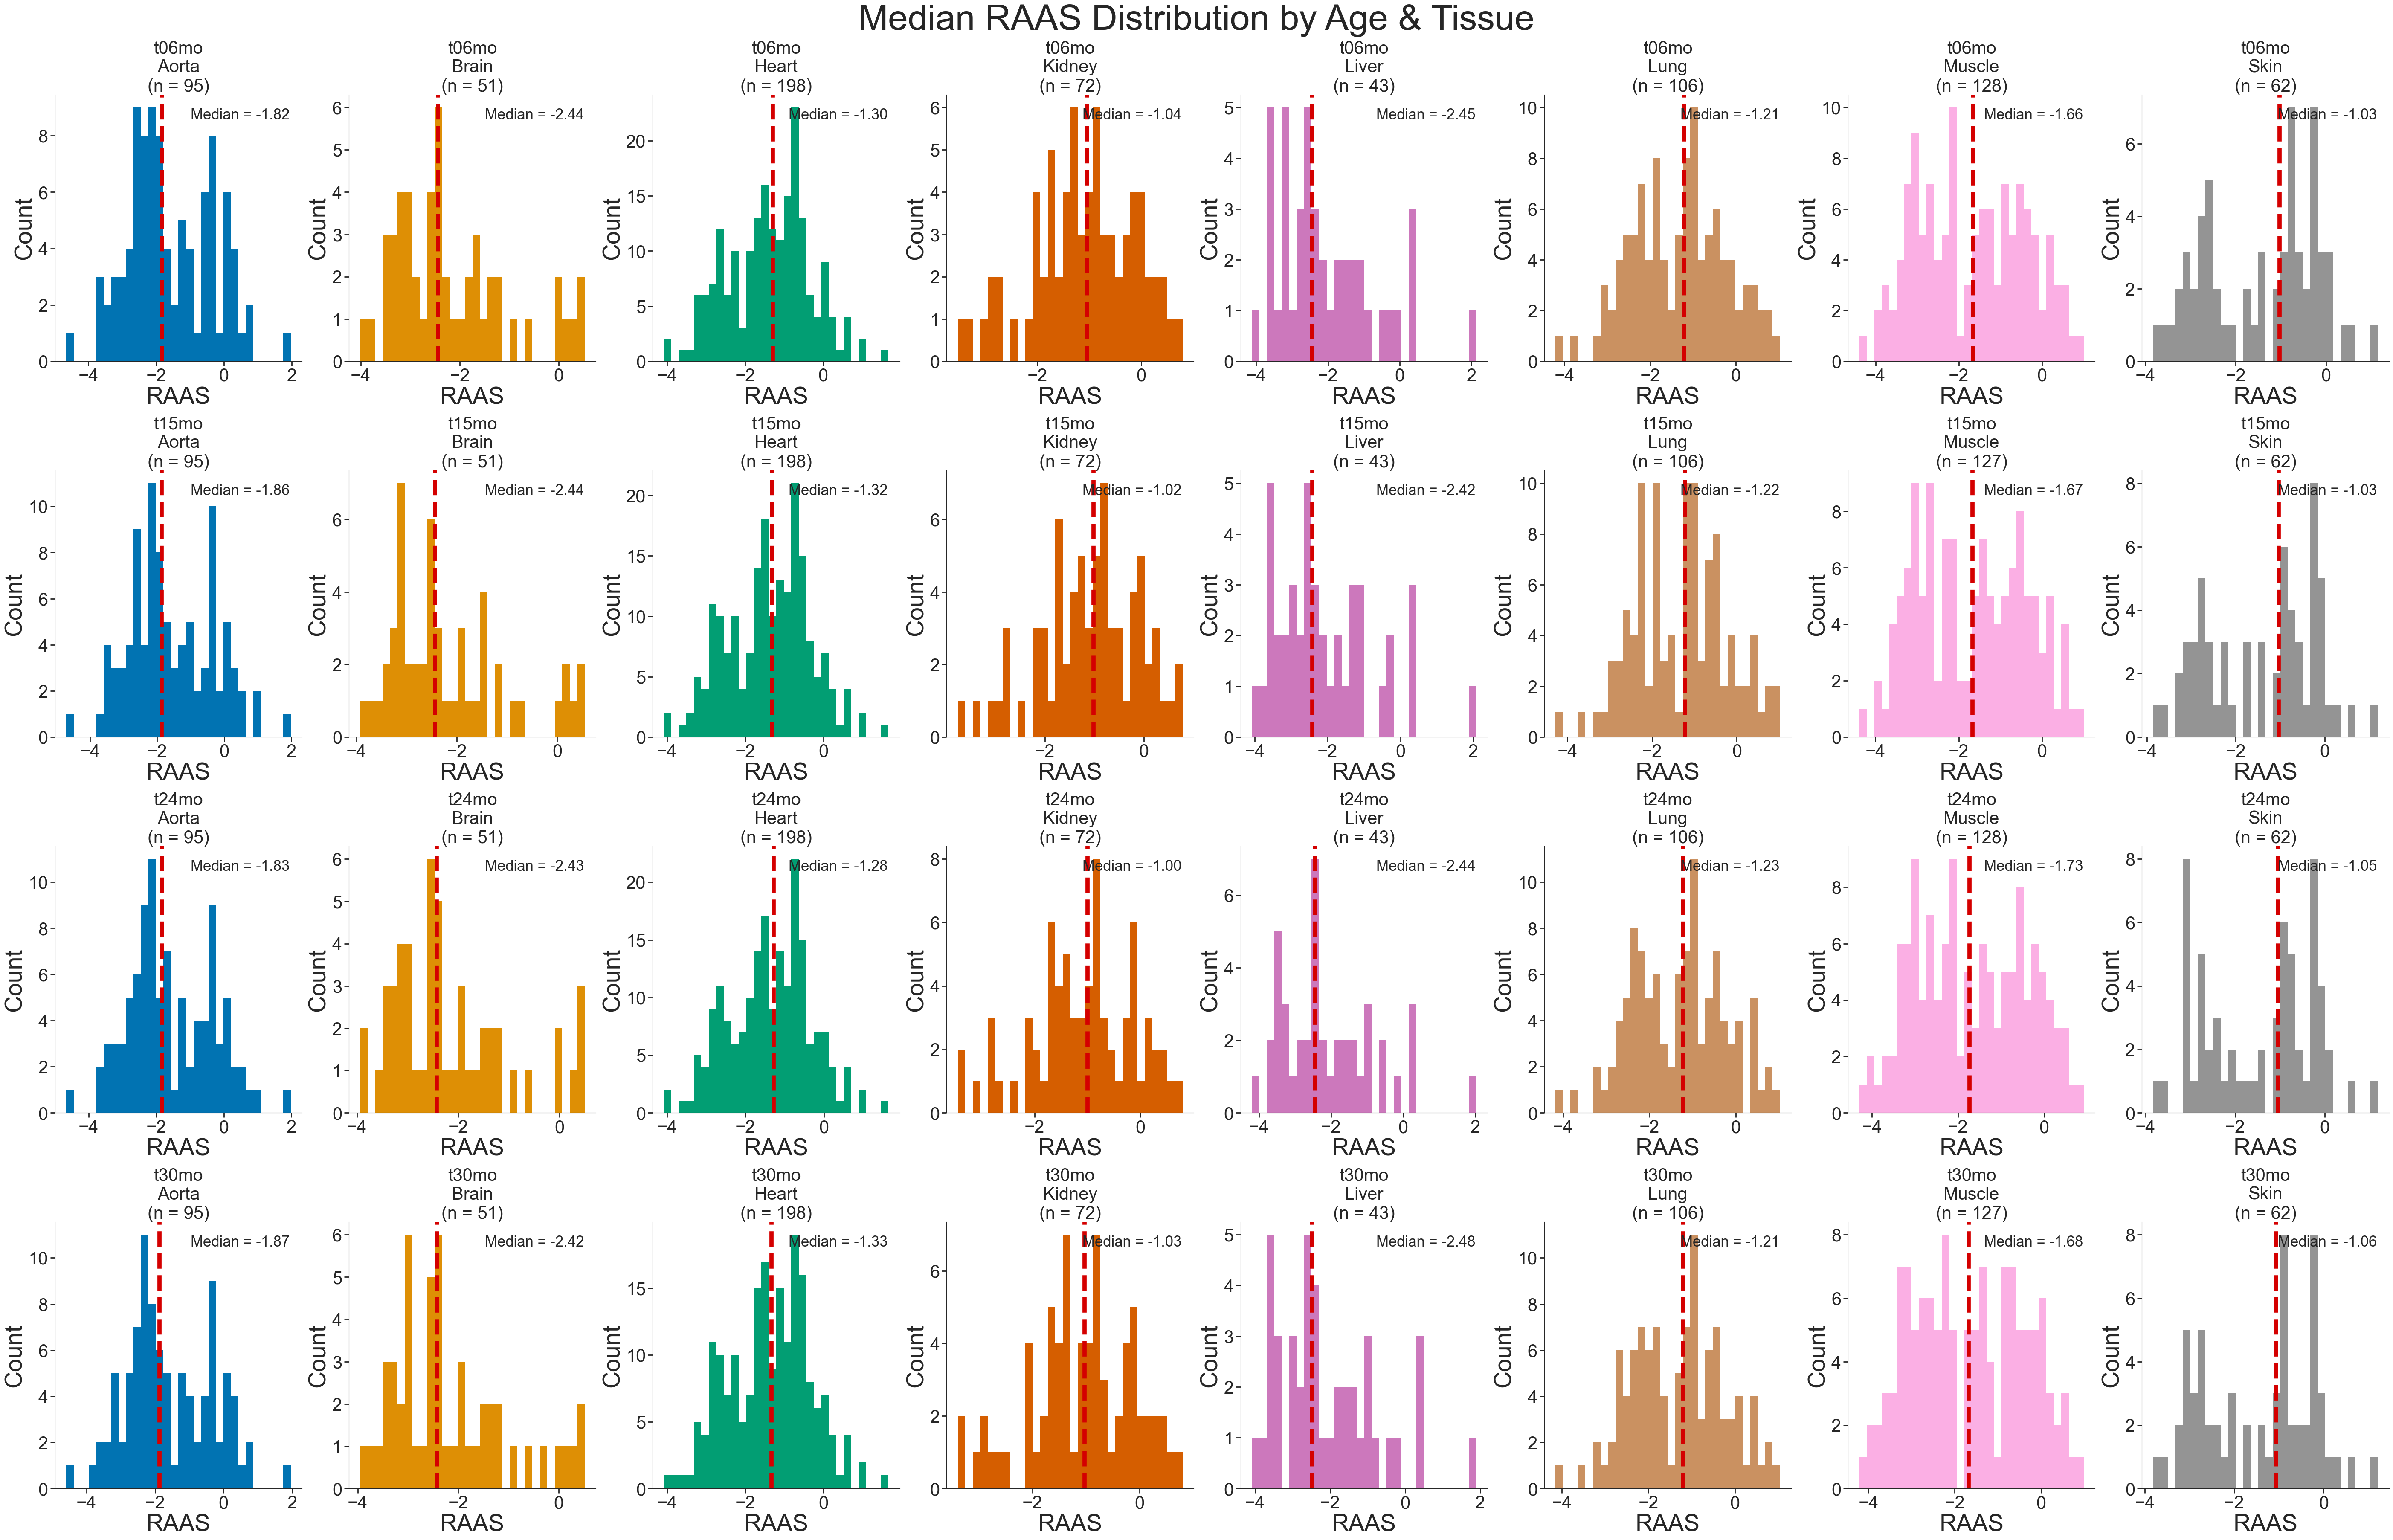

In [459]:
# sample level RAAS distribution by tissue by age
# one SAAP RAAS value is the median of its replicates 

tissue_age_df = SAAP_quant_df.copy()
tissue_age_df = tissue_age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = tissue_age_df['Sample Type'].unique()
tissues = tissue_age_df['Dataset'].unique()

palette = sns.color_palette('colorblind', len(tissues))
tissue_colors = {
    tissue: palette[i]
    for i, tissue in enumerate(tissues)
}

num_ages = len(ages)
num_tissues = len(tissues)

fig,axes = plt.subplots(num_ages, num_tissues, figsize=(7*num_tissues, 9*num_ages), sharey=False, constrained_layout=True)

for i, age in enumerate(ages):
    for j, tissue in enumerate(tissues):
        ax = axes[i,j]
        subset = tissue_age_df[(tissue_age_df['Sample Type'] == age) &
                               (tissue_age_df['Dataset'] == tissue)]
        vals = subset['Reporter_RAAS'].values
        vals = vals[np.isfinite(vals)] 

        sns.set_style('ticks')  
        sns.histplot(vals, bins=30, kde=False, ax=ax,
                     color=tissue_colors[tissue], edgecolor=None, linewidth=0,alpha=1)

        median = np.median(vals) if len(vals) else np.nan
        ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

        n = len(vals)
        ax.set_title(f'{age}\n{tissue}\n(n = {n})', fontsize=30)
        ax.tick_params(axis='both', labelsize=30, length=8, width=2)
        ax.set_xlabel('RAAS', fontsize=40)
        ax.set_ylabel('Count', fontsize=40)
        ax.grid(False)
        sns.despine()

        ax.text(0.55, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
                fontsize=25, verticalalignment='top')

plt.suptitle('Median RAAS Distribution by Age & Tissue',fontsize=60)

plt.savefig(PLOT_DIR + 'Global_RAAS_by_agextissue.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Global_RAAS_by_agextissue.png', dpi=600, bbox_inches='tight')

# 3. RAAS Changes Associated with Aging

## 3a Data pre-processing

In [460]:
COMPLETE_SAAPS_ONLY = True # toggle True if wanting SAAPs detected in EVERY age group
SAAP_KEYS     = ['MTP_seq', 'BP_seq', 'aa_sub']   
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

# Functions to prepare data for analysis
def data_prep(df):
    saap_df = df.copy()
    saap_df['Replicate'] = saap_df['Sample'].str.extract(r'_rep(\d+)_',expand=False)
    saap_df['Replicate'] = pd.to_numeric(saap_df['Replicate'], errors='coerce')
    saap_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
    return saap_df

def filter_complete_saaps(df, *, age_col='Age', saap_keys=SAAP_KEYS,
                          within=None, complete_only=None):
    complete_only = COMPLETE_SAAPS_ONLY if complete_only is None else complete_only
    if not complete_only or age_col not in df.columns:
        return df
    grp = (within or []) + list(saap_keys)
    states = [a for a in age_order if a in df[age_col].unique()]
    present = (df[grp + [age_col]].drop_duplicates()
               .groupby(grp, observed=True)[age_col].nunique())
    keep = present[present == len(states)].reset_index()[grp]
    return df.merge(keep, on=grp, how='inner')

In [461]:
# Prepare data for analysis
SAAP_quant_df = data_prep(SAAP_quant_df) # Add replicate number columns for statistics
SAAP_quant_df=filter_complete_saaps(SAAP_quant_df) # Keep only SAAPs seen across all age groups
print(SAAP_quant_df)

      Dataset                        MTP_seq                         BP_seq  \
0       Aorta                       PFLENVIR                       VFLENVIR   
1       Aorta                       PFLENVIR                       VFLENVIR   
2       Aorta                       PFLENVIR                       VFLENVIR   
3       Aorta                       PFLENVIR                       VFLENVIR   
4       Aorta                       PFLENVIR                       VFLENVIR   
...       ...                            ...                            ...   
13067    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
13068    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
13069    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
13070    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
13071    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   

       aa_sub tmt_set  Positional_probability  spec

In [462]:
# create dictionary with fold changes for each SAAP's RAAS computed between normal (young) and aged samples
# Adapted from the human tumor-vs-normal design (Code_for_Figure_5), but mouse cohorts are CROSS-SECTIONAL:
# 4 independent replicate mice per age group, so there is NO within-subject pairing. The comparison unit is
# therefore the GROUP, not the mouse: each aged age-group summary is compared to the YOUNG (t06mo) group
# summary, per SAAP -> one fold change per (SAAP, aged timepoint).
#   Log2 Aged/Young RAAS = (agg(log10_RAAS_aged) - agg(log10_RAAS_young)) * log2(10)
# Input SAAP_quant_df is already replicate-tagged (and optionally completeness-filtered) in the cells above.

AGG        = 'mean'                 # group summary stat: 'mean' matches normalize_logfc (Ping); 'median' is outlier-robust
BASELINE   = 't06mo'                # young baseline age group (value in 'Sample Type')
AGE_COL    = 'Sample Type'          # age axis (this dataset has no separate 'Age' column)
SAAP_ABUND = 'MTP_ReportInt_Norm'   # normalized SAAP (MTP) report intensity -> SAAP abundance
BP_ABUND   = 'BP_ReportInt_Norm'    # normalized base-peptide report intensity -> BP abundance
FC_OUTFILE = 'Aged_v_Young_RAAS_fold_change_data.p'

def build_aging_fold_change_dict(df, *, agg=AGG, baseline=BASELINE, saap_keys=SAAP_KEYS, age_col=AGE_COL):
    # {tissue: DataFrame of per-SAAP log2 fold changes, aged age-group summary vs the young (t06mo) summary}
    out = {}
    for tissue in sorted(df['Dataset'].dropna().unique()):
        t_df = df.loc[df['Dataset'] == tissue]

        # per-SAAP, per-age-group summary (mean or median of RAAS / abundances; rep count is always a count)
        grp = (t_df.groupby(saap_keys + [age_col], observed=True)
                   .agg(raas=('Reporter_RAAS', agg), saap=(SAAP_ABUND, agg),
                        bp=(BP_ABUND, agg), n=('Sample', 'nunique'))
                   .reset_index())

        young = (grp.loc[grp[age_col] == baseline].drop(columns=age_col)
                    .rename(columns={'raas': 'young_raas', 'saap': 'young_saap',
                                     'bp': 'young_bp', 'n': 'n_young'}))
        aged = grp.loc[grp[age_col] != baseline].merge(young, on=saap_keys, how='inner')
        if aged.empty:
            out[tissue] = pd.DataFrame()
            print(f"{tissue}: no SAAPs with a {baseline} baseline")
            continue

        # RAAS is already log10, so the log2 fold change is a scaled difference
        aged['Log2 Aged/Young RAAS'] = (aged['raas'] - aged['young_raas']) * np.log2(10)
        aged['Log2 Aged/Young SAAP'] = np.log2(aged['saap'] / aged['young_saap'])
        aged['Log2 Aged/Young BP']   = np.log2(aged['bp']   / aged['young_bp'])
        aged['Dataset'] = tissue
        aged['Baseline'] = baseline
        # zero report intensities produce +/-inf log ratios; treat them as missing
        aged = aged.replace([np.inf, -np.inf], np.nan)

        out[tissue] = aged.rename(columns={
            age_col: 'Age group', 'raas': 'Aged RAAS', 'saap': 'Aged SAAP', 'bp': 'Aged BP',
            'young_saap': 'Young SAAP', 'young_bp': 'Young BP', 'young_raas': 'Young RAAS',
            'n': 'n aged reps', 'n_young': 'n young reps'})[[
            'Dataset', *saap_keys, 'Age group', 'Baseline',
            'Aged SAAP', 'Young SAAP', 'Log2 Aged/Young SAAP',
            'Aged BP',   'Young BP',   'Log2 Aged/Young BP',
            'Aged RAAS', 'Young RAAS', 'Log2 Aged/Young RAAS',
            'n aged reps', 'n young reps']]
        print(f"{tissue}: {len(out[tissue]):,} (SAAP x aged-timepoint) fold changes "
              f"across {out[tissue][saap_keys].drop_duplicates().shape[0]} SAAPs")
    return out

aging_fc_dict = build_aging_fold_change_dict(SAAP_quant_df)
pickle.dump(aging_fc_dict, open(OUTDIR + FC_OUTFILE, 'wb'))
print(f"\nWrote {OUTDIR + FC_OUTFILE} (group summary: {AGG})")

Aorta: 300 (SAAP x aged-timepoint) fold changes across 100 SAAPs
Brain: 177 (SAAP x aged-timepoint) fold changes across 59 SAAPs
Heart: 651 (SAAP x aged-timepoint) fold changes across 217 SAAPs
Kidney: 243 (SAAP x aged-timepoint) fold changes across 81 SAAPs
Liver: 156 (SAAP x aged-timepoint) fold changes across 52 SAAPs
Lung: 336 (SAAP x aged-timepoint) fold changes across 112 SAAPs
Muscle: 399 (SAAP x aged-timepoint) fold changes across 133 SAAPs
Skin: 189 (SAAP x aged-timepoint) fold changes across 63 SAAPs

Wrote /Users/alexmaropakis/Projects/BrainDecode/Dependencies/Analysis_Outputs/Takasugi_2024/Aged_v_Young_RAAS_fold_change_data.p (group summary: mean)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 3b RAAS fold change distributions

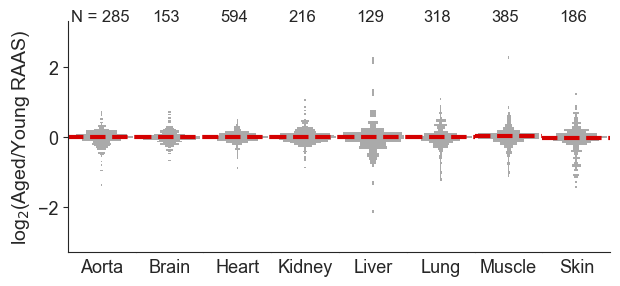

In [463]:
# plot overall distribution of aged vs young RAAS fold change for each SAAP, per tissue
# pools all (SAAP x aged-timepoint) fold changes within a tissue (mirrors the human per-patient pooling)
# aging_fc_dict = pickle.load(open(OUTDIR+'Aged_v_Young_RAAS_fold_change_data.p','rb'))
fc_dict = aging_fc_dict
fc_tissues = [t for t in datasets if t in fc_dict and not fc_dict[t].empty]

col2plot = 'Log2 Aged/Young RAAS'

sns.set_style('ticks')
fig, axes = plt.subplots(1, len(fc_tissues), figsize=(7, 3), sharey=True)

plt.subplots_adjust(wspace=0)
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False, labelbottom=False)
    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# sort tissues in plot by median of distribution
medians = []
for t in fc_tissues:
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    medians.append(np.median(data))
# med_sort_idx = list(np.argsort(medians))
med_sort_idx = [tissue_order.index(ds) for ds in datasets]

for i, t in enumerate(fc_tissues):
    # print(t)
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(t, fontsize=13)
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    bihist(data, data, nbins=60, h=axes[ax_idx])
    if ax_idx == 0:
        axes[ax_idx].annotate('N = '+str(len(data)), (0.05, 1), xycoords='axes fraction', fontsize=12)
    else:
        axes[ax_idx].annotate(str(len(data)), (0.25, 1), xycoords='axes fraction', fontsize=12)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(data), np.median(data)), '--', color='#d40000', linewidth=3)
axes[0].set_ylabel('log$_2$(Aged/Young RAAS)', fontsize=14)
axes[0].tick_params('both', labelsize=13)
# axes[0].set_yticks([-2, -1, 0, 1, 2])

plt.savefig(PLOT_DIR + 'Aged_v_Young_RAAS_bihist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Aged_v_Young_RAAS_bihist.png', dpi=600, bbox_inches='tight')

## 3c Per-SAAP pairwise RAAS significance with age

### Assumption Diagnostics

In [464]:
print(tissue_order) # defined earlier but re-define here if needed 
# tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']
SAAP_KEYS     = ['MTP_seq', 'BP_seq', 'aa_sub']   
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
baseline = 't06mo' # young/healthy age 
aged = [x for x in age_order if x != baseline] # comparison groups  
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']
min_reps = 4 # min number of replicates present for a SAAP to conduct any test 
min_saap = 15 # min number of saap observations total
sig = 0.05 # significance cap 
USE_FDR = True # Option to toggle on BH-FDR correction and the type of statistical test used 

['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']


In [465]:
def sig_col(): return 'FDR' if USE_FDR else 'p_value'
def sig_label(): return 'FDR' if USE_FDR else 'p'

# tidy replicate table: one finite log10 RAAS per (tissue, SAAP, mouse)
raas_rep_df = SAAP_quant_df[['Dataset', *SAAP_KEYS, 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_rep_df['Reporter_RAAS'] = pd.to_numeric(raas_rep_df['Reporter_RAAS'], errors='coerce')
raas_rep_df = raas_rep_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])

# Helper functions
def run_fdr(df, p_col, out_col='FDR'):
    # Benjamini-Hochberg across rows, preserving NaN p-values 
    df = df.copy()
    df[out_col] = np.nan 
    ok = df[p_col].notna()
    if ok.any():
        df.loc[ok, out_col] = multipletests(df.loc[ok, p_col], method='fdr_bh')[1]
    return df  

def fdr_within(df, p_col, group_col, out_col='FDR'):
    # BH-FDR across SAAPs within each age group/comparison
    if df.empty:
        return df
    return pd.concat([run_fdr(g,p_col,out_col) for _, g in df.groupby(group_col)], ignore_index=True)

def iter_saaps(rep=None, age_col='Sample Type'):
    # yield (tissue, saap_key_tuple, {age: RAAS array}, group_df) for each tissue x SAAP 
    rep = raas_rep_df if rep is None else rep
    for (tissue, *keys), g in rep.groupby(['Dataset', *SAAP_KEYS], observed=True):
        by_age = {a: v['Reporter_RAAS'].values for a, v in g.groupby(age_col, observed=True)}
        yield tissue, tuple(keys), by_age, g

def sig_summary(df, p_col, label_col):
    # n significant SAAPs (raw p and FDR) per comparison 
    for lab, g in df.groupby(label_col):
        print(f"    {lab:18} tested={len(g):4d} p<={sig}: {int((g[p_col]<=sig).sum()):4d}"
              f"    FDR<={sig}: {int((g['FDR']<=sig).sum()):4d}")

print(f"{len(raas_rep_df):,} replicate RAAS values across "
      f"{raas_rep_df.groupby(['Dataset',*SAAP_KEYS],observed=True).ngroups:,} tissue x SAAP groups")

12,082 replicate RAAS values across 756 tissue x SAAP groups


### Normality and variance diagnostics for RAAS values across age groups
##### Goal: test whether RAAS changes across age groups
##### Questions: is the data normally distributed? Is the variance equal across groups? 

--- (C) Shapiro-Wilk normality of POOLED residuals (Studentized residual (per-SAAP)), per tissue + global ---
    residual = replicate RAAS - (tissue x SAAP x age) group mean; Shapiro on capped subsample (n <= 300)
 scope  n_sub      W      p    skew  kurtosis      normal?
 Aorta    300 0.9939 0.2714  0.0907   -0.1971 looks normal
 Brain    300 0.9968 0.8239 -0.0179   -0.4162 looks normal
 Heart    300 0.9936 0.2323 -0.0538   -0.2982 looks normal
Kidney    300 0.9979 0.9691  0.1460   -0.0234 looks normal
 Liver    300 0.9949 0.4179  0.0132   -0.1836 looks normal
  Lung    300 0.9910 0.0631  0.1462   -0.0304 looks normal
Muscle    300 0.9934 0.2099 -0.0075   -0.4072 looks normal
  Skin    300 0.9946 0.3748  0.1570   -0.1423 looks normal
GLOBAL    300 0.9946 0.3670  0.0429   -0.2288 looks normal

global: W=0.9946, p=0.367 (skew=0.04, kurtosis=-0.23)  ->  looks normal
  -> if residuals look normal, parametric tests on RAAS are justified (the assumption is on residuals).


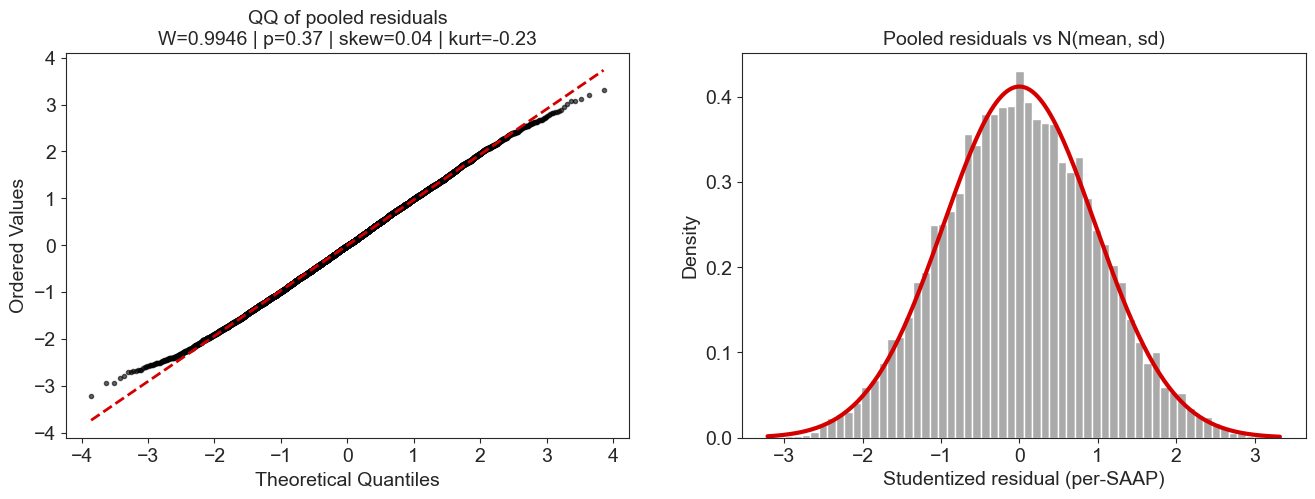

In [466]:
# ============================================================================
# (C) Normality assumption check -- Shapiro-Wilk on POOLED RESIDUALS (the correct way with
# replicates): residual = each replicate's RAAS minus its (tissue x SAAP x age) GROUP MEAN.
# Pool all residuals into ONE sample and test THAT for normality -- parametric tests assume
# the residuals are normal, not the raw values (which differ by group mean). Reporter_RAAS
# is ALREADY log10 -- never re-log. Per tissue + global. Shapiro over-rejects at large n ->
# capped random subsample.
#
# STANDARDIZE_RESIDUALS: different SAAPs have different replicate spreads, so pooling RAW
# residuals mixes scales and creates ARTIFACTUAL heavy tails. Dividing each residual by its
# SAAP's pooled residual SD (Studentizing) removes that artifact -- the proper normality check.
# ============================================================================
STANDARDIZE_RESIDUALS = True
alpha = 0.05; CAP = 300
rng = np.random.RandomState(0)

ds = raas_rep_df.copy()                                  # Reporter_RAAS already log10
ds['resid'] = (ds['Reporter_RAAS']
               - ds.groupby(['Dataset', *SAAP_KEYS, 'Sample Type'], observed=True)['Reporter_RAAS'].transform('mean'))
if STANDARDIZE_RESIDUALS:
    ds['resid'] = ds['resid'] / ds.groupby(['Dataset', *SAAP_KEYS], observed=True)['resid'].transform('std').replace(0, np.nan)
ds = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=['resid'])
rlabel = 'Studentized residual (per-SAAP)' if STANDARDIZE_RESIDUALS else 'raw residual (RAAS - group mean)'

def shapiro_capped(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if len(x) < 3:
        return {'n_sub': len(x), 'W': np.nan, 'p': np.nan, 'skew': np.nan, 'kurtosis': np.nan}
    xs = rng.choice(x, CAP, replace=False) if len(x) > CAP else x
    W, p = stats.shapiro(xs)
    return {'n_sub': len(xs), 'W': W, 'p': p, 'skew': stats.skew(x), 'kurtosis': stats.kurtosis(x)}

tissues = [t for t in tissue_order if t in ds['Dataset'].unique()]
recs = [{'scope': t, **shapiro_capped(ds.loc[ds['Dataset'] == t, 'resid'])} for t in tissues]
recs.append({'scope': 'GLOBAL', **shapiro_capped(ds['resid'])})
shap_df = pd.DataFrame(recs)
shap_df['normal?'] = np.where(shap_df['p'] > alpha, 'looks normal', 'NOT normal')

print(f"--- (C) Shapiro-Wilk normality of POOLED residuals ({rlabel}), per tissue + global ---")
print(f"    residual = replicate RAAS - (tissue x SAAP x age) group mean; Shapiro on capped subsample (n <= {CAP})")
print(shap_df.round(4).to_string(index=False))
g = shap_df[shap_df['scope'] == 'GLOBAL'].iloc[0]
print(f"\nglobal: W={g['W']:.4f}, p={g['p']:.3g} (skew={g['skew']:.2f}, kurtosis={g['kurtosis']:.2f})  ->  {g['normal?']}")
print("  -> if residuals look normal, parametric tests on RAAS are justified (the assumption is on residuals).")

# QQ + histogram on the GLOBAL pooled residuals (native scale, N(mean,sd) overlay)
vals = ds['resid'].to_numpy(); vals = vals[np.isfinite(vals)]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
stats.probplot(vals, dist='norm', plot=ax[0])
ax[0].get_lines()[0].set(color='#000000', ms=3, alpha=0.6)
ax[0].get_lines()[1].set(color='#d40000', lw=2, ls='--')
ax[0].set_title(f'QQ of pooled residuals\nW={g["W"]:.4f} | p={g["p"]:.2g} | '
                f'skew={stats.skew(vals):.2f} | kurt={stats.kurtosis(vals):.2f}', fontsize=14)
ax[0].set_xlabel('Theoretical Quantiles', fontsize=14); ax[0].set_ylabel('Ordered Values', fontsize=14)
ax[0].tick_params(axis='both', labelsize=14)
mu, sdv = vals.mean(), vals.std()
xs = np.linspace(vals.min(), vals.max(), 200)
ax[1].hist(vals, bins=60, density=True, color='#aaaaaa')
ax[1].plot(xs, stats.norm.pdf(xs, mu, sdv), color='#d40000', lw=3)
ax[1].set_title('Pooled residuals vs N(mean, sd)', fontsize=14)
ax[1].set_xlabel(rlabel, fontsize=14); ax[1].set_ylabel('Density', fontsize=14)
ax[1].tick_params(axis='both', labelsize=14)
plt.savefig(PLOT_DIR + 'Aging_RAAS_normality.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Aging_RAAS_normality.png', dpi=600, bbox_inches='tight')
plt.show()


### Is the within-group variance of RAAS the same across 4 age groups? 

In [467]:
"""
QUESTION: does the WITHIN-AGE-GROUP RAAS distribution change in spread (variance) over
aging -- per tissue AND globally?

UNIT = AGE GROUP. The replicate mice are NOT the unit -- they only sharpen each SAAP's
estimate -- so we COLLAPSE them: one RAAS per (tissue, SAAP, age) = mean over replicates.
Within an age group we then have the distribution of per-SAAP RAAS (the RAAS "landscape");
we test whether the SPREAD of that distribution differs across the 4 ages. This removes
the replicate-level pseudoreplication that otherwise inflates n and flags trivial
differences as significant.

  - No SAAP-centering. Reporter_RAAS is ALREADY log10 -- never re-log.
  - Levene (Brown-Forsythe) + Fligner-Killeen across ages; neither assumes normality.
  - BH-FDR across the 8 tissues; GLOBAL kept out of that family.
  - n per age group = number of SAAPs measured at that age (NOT x replicates).
"""
import scipy.stats as stats

AGG = 'mean'   # collapse replicate mice -> one RAAS per (tissue, SAAP, age). 'mean' = best estimate; 'median' = robust

d = raas_rep_df.copy()                                   # Reporter_RAAS already log10
raas_age = (d.groupby(['Dataset', *SAAP_KEYS, 'Sample Type'], observed=True)['Reporter_RAAS']
            .agg(AGG).reset_index())                     # one row per tissue x SAAP x age
raas_age = raas_age.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])

def variance_across_ages(df):
    """Levene (Brown-Forsythe) + Fligner-Killeen on per-SAAP RAAS across the age groups."""
    groups = [g['Reporter_RAAS'].values for _, g in df.groupby('Sample Type', observed=True) if len(g) >= 2]
    n_saap = df.drop_duplicates(subset=SAAP_KEYS).shape[0]
    if len(groups) < 2:
        return {'n_saap': n_saap, 'n_pts': len(df), 'levene_p': np.nan, 'fligner_p': np.nan}
    return {'n_saap': n_saap, 'n_pts': int(sum(map(len, groups))),
            'levene_p':  stats.levene(*groups, center='median').pvalue,
            'fligner_p': stats.fligner(*groups).pvalue}

tissues = [t for t in tissue_order if t in raas_age['Dataset'].unique()]
recs = [{'scope': t, **variance_across_ages(raas_age[raas_age['Dataset'] == t])} for t in tissues]
recs.append({'scope': 'GLOBAL', **variance_across_ages(raas_age)})
var_df = pd.DataFrame(recs)

ok = (var_df['scope'] != 'GLOBAL') & var_df['levene_p'].notna()
for c in ['levene', 'fligner']:
    var_df.loc[ok, f'{c}_FDR'] = multipletests(var_df.loc[ok, f'{c}_p'], method='fdr_bh')[1]
var_df['verdict'] = np.where(var_df['levene_p'] <= sig, 'variance DIFFERS across ages', 'no detected difference')

cols = ['scope', 'n_saap', 'n_pts', 'levene_p', 'fligner_p', 'levene_FDR', 'fligner_FDR', 'verdict']
print(f"--- Within-age-group RAAS variance across ages (replicates collapsed by {AGG}); Levene + Fligner, log10 RAAS ---")
print("    unit = one RAAS per (tissue x SAAP x age);  n_saap = unique SAAPs;  n_pts = SAAP x age points")
print(var_df[cols].round(4).to_string(index=False))
tis = var_df[var_df['scope'] != 'GLOBAL']; g = var_df[var_df['scope'] == 'GLOBAL'].iloc[0]
n_sig = int((tis['levene_FDR'] <= sig).sum())
print(f"\nper tissue: {n_sig}/{int(tis['levene_p'].notna().sum())} tissues show UNEQUAL variance (Levene BH-FDR<={sig})")
print(f"global:     Levene p={g['levene_p']:.3g}, Fligner p={g['fligner_p']:.3g}  ->  {g['verdict']}")


--- Within-age-group RAAS variance across ages (replicates collapsed by mean); Levene + Fligner, log10 RAAS ---
    unit = one RAAS per (tissue x SAAP x age);  n_saap = unique SAAPs;  n_pts = SAAP x age points
 scope  n_saap  n_pts  levene_p  fligner_p  levene_FDR  fligner_FDR                verdict
 Aorta      95    380    1.0000     0.9990         1.0       0.9997 no detected difference
 Brain      51    204    0.9999     0.9973         1.0       0.9997 no detected difference
 Heart     198    792    0.9998     0.9997         1.0       0.9997 no detected difference
Kidney      72    288    0.9997     0.9982         1.0       0.9997 no detected difference
 Liver      43    172    0.9998     0.9993         1.0       0.9997 no detected difference
  Lung     106    424    0.9992     0.9978         1.0       0.9997 no detected difference
Muscle     129    514    0.9937     0.9912         1.0       0.9997 no detected difference
  Skin      62    248    0.9998     0.9984         1.0       0

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

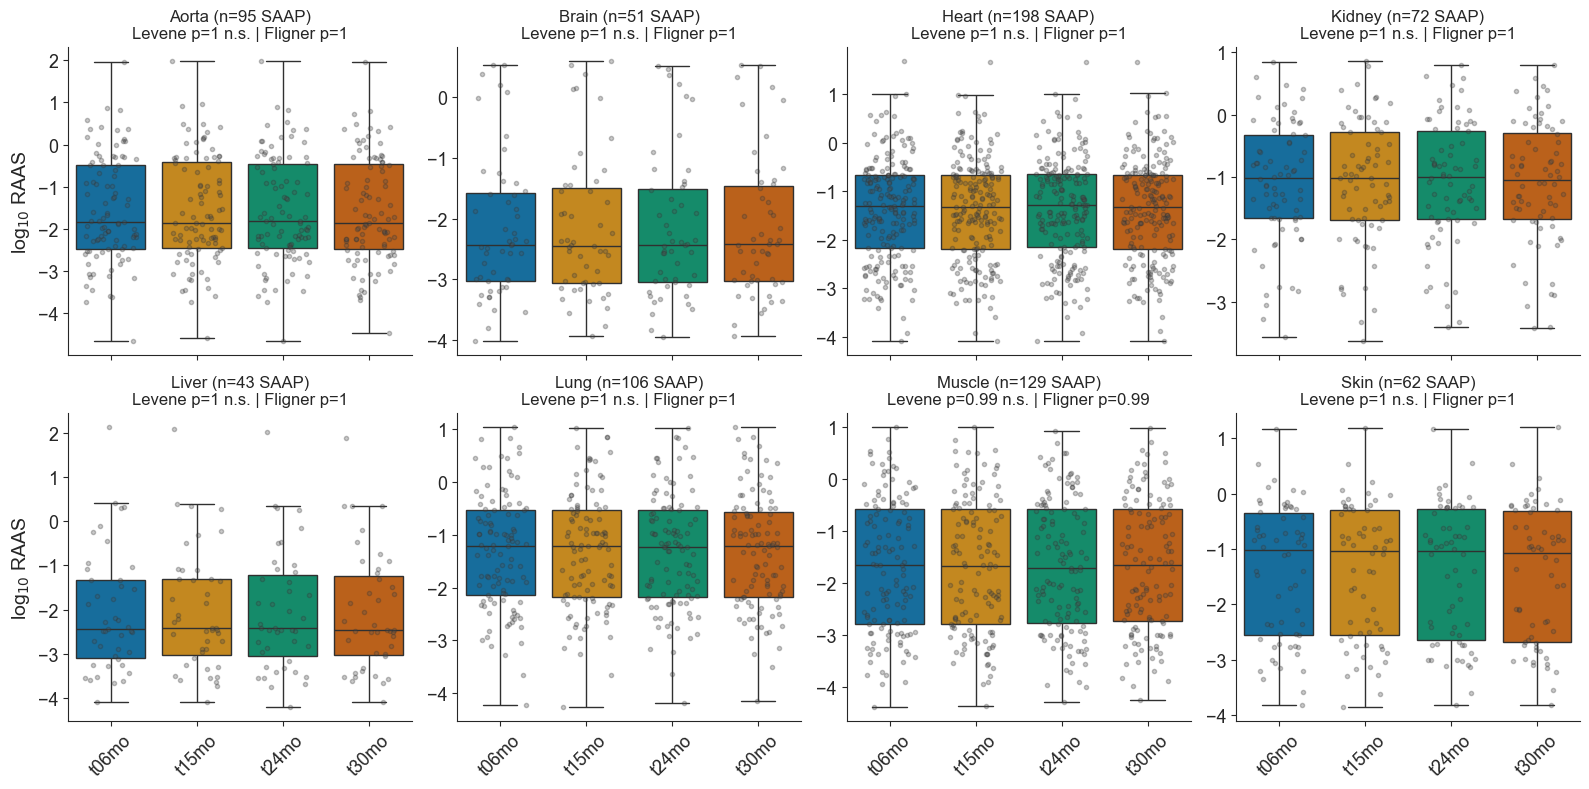

In [468]:
# Within-age-group RAAS spread across ages, PER TISSUE (2 rows x 4 cols).
# Each point = one SAAP's replicate-collapsed RAAS; box = the RAAS distribution at
# that age. Equal box heights across ages = equal variance. n = unique SAAPs.

sns.set_style('ticks')

def sig_stars(p):
    return ('***' if p <= 1e-3 else '**' if p <= 1e-2 else '*' if p <= 5e-2 else 'n.s.') if pd.notna(p) else 'NA'

ncol = 4; nrow = int(np.ceil(len(tissues) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow), sharex=True)
axes = np.atleast_1d(axes).reshape(-1)
for i, (ax, t) in enumerate(zip(axes, tissues)):
    dd = raas_age[raas_age['Dataset'] == t]
    sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
                linewidth=1, fliersize=0, ax=ax)
    sns.stripplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, ax=ax,
                  color='#525252', size=3, alpha=0.3, jitter=0.3, linewidth=1)
    r = var_df[var_df['scope'] == t].iloc[0]
    ax.set_title(f"{t} (n={int(r['n_saap'])} SAAP)\n"
                 f"Levene p={r['levene_p']:.2g} {sig_stars(r.get('levene_FDR', np.nan))} | Fligner p={r['fligner_p']:.2g}",
                 fontsize=12)
    ax.set_xlabel(''); ax.set_ylabel('log$_{10}$ RAAS' if i % ncol == 0 else '', fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    sns.despine(ax=ax)
for ax in axes[len(tissues):]:
    ax.set_visible(False)
fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_variance_by_tissue.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_variance_by_tissue.png', dpi=600, bbox_inches='tight')
plt.show()


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/3757211738.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',


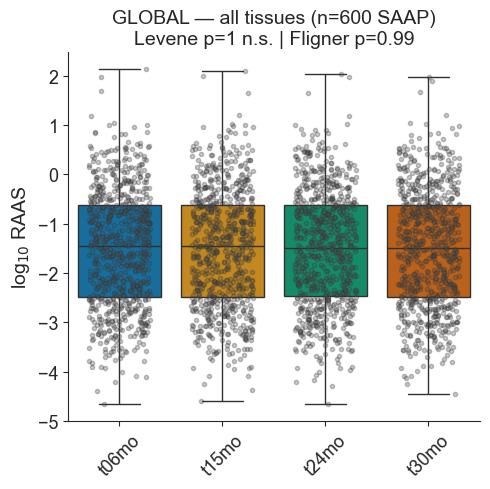

In [469]:
# Within-age-group RAAS spread across ages, GLOBAL (all tissues pooled, replicates collapsed).

sns.set_style('ticks')

def sig_stars(p):
    return ('***' if p <= 1e-3 else '**' if p <= 1e-2 else '*' if p <= 5e-2 else 'n.s.') if pd.notna(p) else 'NA'

g = var_df[var_df['scope'] == 'GLOBAL'].iloc[0]
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
            linewidth=1, fliersize=0, ax=ax)
sns.stripplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, ax=ax,
              color='#525252', size=3, alpha=0.3, jitter=0.3, linewidth=1)
ax.set_title(f"GLOBAL — all tissues (n={int(g['n_saap'])} SAAP)\n"
             f"Levene p={g['levene_p']:.2g} {sig_stars(g['levene_p'])} | Fligner p={g['fligner_p']:.2g}", fontsize=14)
ax.set_xlabel(''); ax.set_ylabel('log$_{10}$ RAAS', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=13)
ax.tick_params(axis='y', labelsize=13)
sns.despine(ax=ax)
fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_variance_global.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_variance_global.png', dpi=600, bbox_inches='tight')
plt.show()


### What are the significant SAAP-level changes with aging within tissues?

In [470]:
# Per-SAAP pairwise Student's t-test of log10 RAAS: each aged age vs the 6mo (t06mo) baseline,
#      WITHIN each tissue. Equal-variance (Student) is justified by the diagnostics above -- pooled
#      residuals are ~normal (Shapiro/QQ, cell 66) and the within-age-group RAAS variance is homogeneous
#      across ages (Levene/Fligner, cell 68). At balanced n=4 the equal-variance pooling recovers the
#      degrees of freedom and power that Welch would forfeit.
#
# Toggles:
#   EQUAL_VAR (here)     -- True = Student's t (equal variance, the justified default); False = Welch's t.
#   USE_FDR (setup cell) -- multiple-hypothesis-correction toggle. BH-FDR is computed across SAAPs *within*
#                           each comparison (the multiplicity family); USE_FDR then flips sig_col()/sig_label()
#                           so every downstream significance call + label uses FDR vs raw p. FDR is always
#                           stored, so the toggle never recomputes -- it only re-points the threshold.
#
# `aging_ttest_df` is the tidy, publication-ready source frame for Supplemental_Data_3 (one row per
# tissue x SAAP x comparison): group means/SDs, log2 fold change, direction, t/df, p_value and FDR.

EQUAL_VAR = True          # Student's t (equal variance); flip to False for Welch's t

def pairwise_student_ttest(rep=None, *, equal_var=EQUAL_VAR):
    """Each aged age vs the t06mo baseline, per (tissue x SAAP), via a two-sample t-test on log10 RAAS.
    BH-FDR is added across SAAPs within each comparison. rep=None -> per-tissue (groups by Dataset x SAAP);
    pass a pooled rep (single Dataset) for an across-tissue cohort."""
    test_name = 'Student' if equal_var else 'Welch'
    rows = []
    for tissue, keys, by_age, _ in iter_saaps(rep):
        base = by_age.get(baseline, np.empty(0))
        if len(base) < min_reps:                       # need the baseline group to test against
            continue
        for a in aged:
            cur = by_age.get(a, np.empty(0))
            if len(cur) < min_reps:                    # skip aged timepoints with too few replicates
                continue
            res = ttest_ind(cur, base, equal_var=equal_var)
            df_t = float(getattr(res, 'df', len(cur) + len(base) - 2))   # scipy>=1.11 exposes .df
            rows.append({
                'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
                'comparison': f'{a} vs {baseline}',
                'n_base': len(base), 'n_aged': len(cur),
                'mean_young_RAAS': base.mean(), 'mean_aged_RAAS': cur.mean(),
                'sd_young_RAAS': base.std(ddof=1), 'sd_aged_RAAS': cur.std(ddof=1),
                'mean_log2FC': (cur.mean() - base.mean()) * np.log2(10),   # RAAS is already log10
                't_stat': float(res.statistic), 'df': df_t, 'p_value': float(res.pvalue),
                'test': test_name})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')   # BH-FDR across SAAPs within comparison
    if not out.empty:
        out['direction'] = np.where(out['mean_log2FC'] >= 0, 'up', 'down')
        out['significant'] = out[sig_col()] <= sig                 # flagged by the active metric (p or FDR)
    return out

aging_ttest_df = pairwise_student_ttest()
pickle.dump(aging_ttest_df, open(OUTDIR + 'Aging_RAAS_pairwise_ttest.p', 'wb'))

print(f"Pairwise {'Student' if EQUAL_VAR else 'Welch'}'s t-test of log10 RAAS, each aged age vs {baseline}, within tissues")
print(f"  multiplicity = BH-FDR across SAAPs within each comparison | significance = {sig_label()} <= {sig}")
print(f"  tested {len(aging_ttest_df):,} (tissue x SAAP x comparison) over "
      f"{aging_ttest_df[['Dataset', *SAAP_KEYS]].drop_duplicates().shape[0]:,} tissue x SAAP groups\n")
sig_summary(aging_ttest_df, 'p_value', 'comparison')

# preview: most significant changers first (display-only formatting; stored columns stay numeric)
_show = ['Dataset', 'aa_sub', 'comparison', 'n_aged', 'mean_log2FC', 'direction', 't_stat', 'p_value', 'FDR']
_prev = aging_ttest_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f'{v:.2e}' if pd.notna(v) else '')
_prev['mean_log2FC'] = _prev['mean_log2FC'].map(lambda v: f'{v:+.3f}')
print(f"\ntop changers by {sig_label()}:")
print(_prev[_show].to_string(index=False))


Pairwise Student's t-test of log10 RAAS, each aged age vs t06mo, within tissues
  multiplicity = BH-FDR across SAAPs within each comparison | significance = FDR <= 0.05
  tested 2,265 (tissue x SAAP x comparison) over 755 tissue x SAAP groups

    t15mo vs t06mo     tested= 755 p<=0.05:   85    FDR<=0.05:    0
    t24mo vs t06mo     tested= 755 p<=0.05:  128    FDR<=0.05:   24
    t30mo vs t06mo     tested= 755 p<=0.05:  146    FDR<=0.05:   35

top changers by FDR:
Dataset aa_sub     comparison  n_aged mean_log2FC direction    t_stat  p_value      FDR
 Muscle T to N t30mo vs t06mo       4      +2.289        up 22.863188 4.59e-07 3.46e-04
 Muscle T to N t24mo vs t06mo       4      +2.276        up 18.125385 1.82e-06 1.37e-03
   Skin A to S t30mo vs t06mo       4      +0.784        up 14.581155 6.53e-06 2.46e-03
 Muscle V to P t30mo vs t06mo       4      +0.559        up 11.417169 2.71e-05 6.81e-03
   Skin H to E t30mo vs t06mo       4      -1.163      down -9.448316 8.00e-05 1.21e-02
  

#### Volcano plot of significant SAAP-level RAAS changes with aging

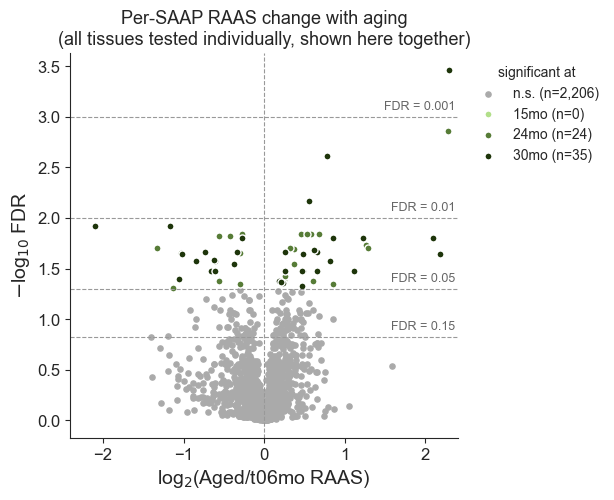


significant SAAP-changes (FDR <= 0.05) plotted by aged timepoint:
age
t15mo     0
t24mo    24
t30mo    35


In [471]:
# Volcano of per-SAAP RAAS changes with aging -- ALL aged timepoints + tissues pooled into one plot.
#      x = mean log2(Aged/Young RAAS) (cur.mean - base.mean, scaled to log2); y = -log10 of the active
#      significance metric (FDR or raw p, per the USE_FDR toggle, via sig_col()/sig_label()).
#      Non-significant SAAPs are grey; significant SAAPs (sig_col() <= sig) are colored by the aged
#      timepoint they were compared against the 6mo baseline at (15mo / 24mo / 30mo). Each (tissue x SAAP
#      x comparison) row in aging_ttest_df (cell above) is one point, so a SAAP can appear up to 3x
#      (once per aged timepoint). Older timepoints are drawn last so they sit on top.

# aging-timepoint palette (warm ramp deepening with age); grey = not significant
AGE_COLORS = {'t15mo': '#b2df8a', 't24mo': "#577c37", 't30mo': "#1e350b"}
NS_COLOR   = '#aaaaaa'

# horizontal reference lines, drawn at -log10 of each value on the active-metric (sig_col()) axis
# SIG_LINES = [0.05, 0.01, 0.001, 0.0001, 0.00001] # pval
SIG_LINES = [0.15, 0.05, 0.01, 0.001] # FDR

def plot_aging_volcano(df, *, age_colors=AGE_COLORS, ns_color=NS_COLOR, sig_lines=SIG_LINES):
    metric = sig_col()                                       # 'FDR' or 'p_value' per USE_FDR
    d = df.dropna(subset=['mean_log2FC', metric]).copy()
    d['age'] = d['comparison'].str.split().str[0]            # 't15mo' from 't15mo vs t06mo'
    # -log10 with a floor so a metric value of 0 (numeric underflow) stays finite/on-scale
    floor = d.loc[d[metric] > 0, metric].min()
    d['neglog10'] = -np.log10(d[metric].clip(lower=floor))

    sns.set_style('ticks')
    fig, ax = plt.subplots(figsize=(5, 5))

    # non-significant background first (significance set earlier in 3c: sig_col() <= sig)
    ns = d[~d['significant']]
    ax.scatter(ns['mean_log2FC'], ns['neglog10'], s=14, color=ns_color, alpha=1,
               linewidths=1, label=f'n.s. (n={len(ns):,})', rasterized=True)
    # significant SAAPs only, colored by aged timepoint, oldest plotted last (on top)
    for age in [a for a in age_order if a in age_colors]:
        sub = d[d['significant'] & (d['age'] == age)]
        ax.scatter(sub['mean_log2FC'], sub['neglog10'], s=26, color=age_colors[age], alpha=1,
                   linewidths=1, edgecolors='white', label=f'{age[1:]} (n={len(sub):,})')

    xlim = np.nanmax(np.abs(d['mean_log2FC'])) * 1.05         # symmetric x so up/down read evenly
    ax.set_xlim(-xlim, xlim)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')

    # horizontal reference lines at the active metric (FDR or p), labeled at the right edge
    for v in sig_lines:
        y = -np.log10(v)
        ax.axhline(y, color='#999999', lw=0.8, ls='--')
        ax.annotate(f'{sig_label()} = {v:g}', (ax.get_xlim()[1], y),
                    xytext=(-2, 3), textcoords='offset points', ha='right', va='bottom',
                    fontsize=9, color='#666666')

    ax.set_xlabel('log$_2$(Aged/t06mo RAAS)', fontsize=14)
    ax.set_ylabel(f'$-$log$_{{10}}$ {sig_label()}', fontsize=14)
    ax.set_title(f'Per-SAAP RAAS change with aging\n(all tissues tested individually, shown here together)', fontsize=13)
    ax.tick_params('both', labelsize=12)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(title='significant at', fontsize=10, title_fontsize=10, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1))

    plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.pdf', bbox_inches='tight')
    plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.png', dpi=600, bbox_inches='tight')
    plt.show()
    return d

_volcano = plot_aging_volcano(aging_ttest_df)
print(f"\nsignificant SAAP-changes ({sig_label()} <= {sig}) plotted by aged timepoint:")
print(_volcano[_volcano['significant']].groupby('age').size().reindex(aged).fillna(0).astype(int).to_string())

In [472]:
# Save as Supplemental_Data_3.1.SAAP_age_related.xlsx  (+ ..._statistics.xlsx)
# A subset of SAAP shown confidently to change across aging and their statistics.
# Built from aging_ttest_df (cell "3c"): "confident changers" = SAAPs significant in >=1 aged-vs-6mo
# comparison by the active metric (sig_col() = FDR if USE_FDR else p_value, threshold = sig).

SAAP_INDEX = ['Dataset', *SAAP_KEYS]

# confident changers: any aged timepoint significant vs the 6mo baseline
confident_keys = (aging_ttest_df.loc[aging_ttest_df[sig_col()] <= sig, SAAP_INDEX]
                  .drop_duplicates())

# statistics table -- every aged-vs-6mo comparison for those confident SAAPs (full stats)
age_related_statistics = (aging_ttest_df.merge(confident_keys, on=SAAP_INDEX)
                          .sort_values(SAAP_INDEX + ['comparison'])
                          .set_index(SAAP_INDEX))

age_related_statistics.to_excel(SUPP_DIR + 'Supplemental_Data_3.2.SAAP_age_related_statistics.xlsx',
                                sheet_name='statistics', index=True)

# (2) SAAP-level subset -- every SAAP_quant_df row for the confident SAAPs, keeping all
# quant columns, with per-timepoint log2FC + significance appended
_fc_wide = (age_related_statistics.reset_index()
            .pivot_table(index=SAAP_INDEX, columns='comparison', values='mean_log2FC'))
_fc_wide.columns = [f'log2FC {c}' for c in _fc_wide.columns]
_sig_wide = (age_related_statistics.reset_index()
             .pivot_table(index=SAAP_INDEX, columns='comparison', values=sig_col()))
_sig_wide.columns = [f'{sig_label()} {c}' for c in _sig_wide.columns]
_stats_block = _fc_wide.join(_sig_wide).reset_index()

age_related_saaps = (SAAP_quant_df.reset_index()
                     .merge(confident_keys, on=SAAP_INDEX, how='inner')
                     .merge(_stats_block, on=SAAP_INDEX, how='left')
                     .sort_values(SAAP_INDEX + ['Sample Type', 'Replicate']))

age_related_saaps.to_excel(SUPP_DIR + 'Supplemental_Data_3.1.SAAP_age_related.xlsx',
                           sheet_name='SAAP_age_related', index=False)

In [473]:
print(age_related_saaps)

     index Dataset       MTP_seq        BP_seq  aa_sub tmt_set  \
13    4349   Heart  DIAMDGTEGLVR  TIAMDGTEGLVR  T to D      S3   
8     4344   Heart  DIAMDGTEGLVR  TIAMDGTEGLVR  T to D      S3   
4     4340   Heart  DIAMDGTEGLVR  TIAMDGTEGLVR  T to D      S3   
12    4348   Heart  DIAMDGTEGLVR  TIAMDGTEGLVR  T to D      S3   
14    4350   Heart  DIAMDGTEGLVR  TIAMDGTEGLVR  T to D      S3   
..     ...     ...           ...           ...     ...     ...   
608  12272    Skin  WTVHLMETLLPR  WPVHLMETLLPR  P to T      S8   
619  12283    Skin  WTVHLMETLLPR  WPVHLMETLLPR  P to T      S8   
622  12286    Skin  WTVHLMETLLPR  WPVHLMETLLPR  P to T      S8   
618  12282    Skin  WTVHLMETLLPR  WPVHLMETLLPR  P to T      S8   
611  12275    Skin  WTVHLMETLLPR  WPVHLMETLLPR  P to T      S8   

     Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  ...  \
13                    0.973             1.102    0.8042    0.0005  ...   
8                     0.973             1.102    0.8042    

#### Compile a gene list for testing substitution favorability in SAAP significantly changed with aging

In [474]:
# age_gene_list = pd.DataFrame({
#     'MTP_seq': age_related_saaps['MTP_seq'],
#     'BP_seq': age_related_saaps['BP_seq'],
#     'swap': age_related_saaps['aa_sub'],
#     'gene': age_related_saaps['Source_gene'],
#     'accession': age_related_saaps['Source_accessions'],
#     'protein': age_related_saaps['Source_protein']
# }).drop_duplicates()

# print(age_gene_list)

# age_gene_list.to_csv(SUPP_DIR + 'Data_4.SAAP_age_related_gene_list.tsv',sep='\t',index=False)


age_gene_list = pd.DataFrame({
    'MTP_seq': age_related_saaps['MTP_seq'],
    'BP_seq': age_related_saaps['BP_seq'],
    'swap': age_related_saaps['aa_sub'],
    'gene': age_related_saaps['Source_gene'],
    'accession': age_related_saaps['Source_accessions'],
    'protein': age_related_saaps['Source_protein']
}).drop_duplicates()

print(age_gene_list)

age_gene_list.to_csv(SUPP_DIR + 'Data_4.SAAP_age_related_gene_list_leading_only.tsv',sep='\t',index=False)

                    MTP_seq                  BP_seq      swap           gene  \
13             DIAMDGTEGLVR            TIAMDGTEGLVR    T to D        Atp5f1b   
61              DSYVGDELQSK             DSYVGDEAQSK  A to I/L          Actc1   
45           PGVPTETGALTLNR          VGVPTETGALTLNR    V to P          Acaa2   
29                 SGIFQSAK                AGIFQSAK    A to S          Cox6c   
121               EATDVVDVK               EATWVVDVK    W to D           Scp2   
105  GGSEVQIFAPDVPQMHVIDHTK  GGAEVQIFAPDVPQMHVIDHTK    A to S          Gatd3   
73                 PFLENVIR                VFLENVIR    V to P           H4c1   
89                TSTDSGESK               TSTWSGESK    W to D            Ncl   
128              GEEGTWSVEK              NEEGTWSVEK    N to G       Selenbp2   
144              LILPGLMSSR              LILPGLISSR    I to M       Selenbp1   
160              NPEGTWSVEK              NEEGTWSVEK    E to P       Selenbp2   
266             DFNDSQLQEGK             

### What are the significant SAAP-level changes with aging globally?

In [475]:
# global  Per-SAAP pairwise Student's t-test of log10 RAAS: each aged age vs the 6mo (t06mo)
#      baseline, POOLED ACROSS ALL TISSUES. For each SAAP, every tissue's replicate RAAS values are
#      pooled per age (grouping by SAAP_KEYS only, dropping Dataset), then each aged age is tested vs
#      the pooled t06mo baseline. Equal-variance (Student) is justified by the diagnostics above.
#
# Toggles:
#   EQUAL_VAR (here)     -- True = Student's t (equal variance, the justified default); False = Welch's t.
#   USE_FDR (setup cell) -- BH-FDR across SAAPs *within* each comparison (the multiplicity family).

EQUAL_VAR = True          # Student's t (equal variance); flip to False for Welch's t

def iter_saaps_global(age_col='Sample Type'):
    """Like iter_saaps but pooled across tissues: group by SAAP_KEYS only (Dataset dropped),
    so each SAAP's per-age array concatenates every tissue's replicate RAAS values.
    Skips SAAPs whose pooled count across all tissues is < min_saap."""
    for keys, g in raas_rep_df.groupby(list(SAAP_KEYS), observed=True):
        if len(g) < min_saap:                          # pooled-across-tissues count gate
            continue
        keys = keys if isinstance(keys, tuple) else (keys,)
        by_age = {a: v['Reporter_RAAS'].values for a, v in g.groupby(age_col, observed=True)}
        yield tuple(keys), by_age, g

def pairwise_student_ttest_global(*, equal_var=EQUAL_VAR):
    """Each aged age vs the t06mo baseline, per SAAP, on log10 RAAS pooled across all tissues.
    BH-FDR is added across SAAPs within each comparison."""
    test_name = 'Student' if equal_var else 'Welch'
    rows = []
    for keys, by_age, _ in iter_saaps_global():
        base = by_age.get(baseline, np.empty(0))
        if len(base) < min_reps:                       # need the baseline group to test against
            continue
        for a in aged:
            cur = by_age.get(a, np.empty(0))
            if len(cur) < min_reps:                    # skip aged timepoints with too few replicates
                continue
            res = ttest_ind(cur, base, equal_var=equal_var)
            df_t = float(getattr(res, 'df', len(cur) + len(base) - 2))   # scipy>=1.11 exposes .df
            rows.append({
                **dict(zip(SAAP_KEYS, keys)),
                'comparison': f'{a} vs {baseline}',
                'n_base': len(base), 'n_aged': len(cur),
                'mean_young_RAAS': base.mean(), 'mean_aged_RAAS': cur.mean(),
                'sd_young_RAAS': base.std(ddof=1), 'sd_aged_RAAS': cur.std(ddof=1),
                'mean_log2FC': (cur.mean() - base.mean()) * np.log2(10),   # RAAS is already log10
                't_stat': float(res.statistic), 'df': df_t, 'p_value': float(res.pvalue),
                'test': test_name})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')   # BH-FDR across SAAPs within comparison
    if not out.empty:
        out['direction'] = np.where(out['mean_log2FC'] >= 0, 'up', 'down')
        out['significant'] = out[sig_col()] <= sig                 # flagged by the active metric (p or FDR)
    return out

aging_ttest_global_df = pairwise_student_ttest_global()
pickle.dump(aging_ttest_global_df, open(OUTDIR + 'Aging_RAAS_pairwise_ttest_global.p', 'wb'))

print(f"Pairwise {'Student' if EQUAL_VAR else 'Welch'}'s t-test of log10 RAAS, each aged age vs {baseline}, POOLED across all tissues")
print(f"  multiplicity = BH-FDR across SAAPs within each comparison | significance = {sig_label()} <= {sig}")
print(f"  tested {len(aging_ttest_global_df):,} (SAAP x comparison) over "
      f"{aging_ttest_global_df[list(SAAP_KEYS)].drop_duplicates().shape[0]:,} SAAP groups\n")
sig_summary(aging_ttest_global_df, 'p_value', 'comparison')

# preview: most significant changers first (display-only formatting; stored columns stay numeric)
_show = ['aa_sub', 'comparison', 'n_aged', 'mean_log2FC', 'direction', 't_stat', 'p_value', 'FDR']
_prev = aging_ttest_global_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f'{v:.2e}' if pd.notna(v) else '')
_prev['mean_log2FC'] = _prev['mean_log2FC'].map(lambda v: f'{v:+.3f}')
print(f"\ntop changers by {sig_label()}:")
print(_prev[_show].to_string(index=False))

Pairwise Student's t-test of log10 RAAS, each aged age vs t06mo, POOLED across all tissues
  multiplicity = BH-FDR across SAAPs within each comparison | significance = FDR <= 0.05
  tested 1,797 (SAAP x comparison) over 599 SAAP groups

    t15mo vs t06mo     tested= 599 p<=0.05:   50    FDR<=0.05:    0
    t24mo vs t06mo     tested= 599 p<=0.05:   89    FDR<=0.05:   13
    t30mo vs t06mo     tested= 599 p<=0.05:   98    FDR<=0.05:   22

top changers by FDR:
aa_sub     comparison  n_aged mean_log2FC direction    t_stat  p_value      FDR
T to N t30mo vs t06mo       4      +2.289        up 22.863188 4.59e-07 2.75e-04
T to N t24mo vs t06mo       4      +2.276        up 18.125385 1.82e-06 1.09e-03
V to P t30mo vs t06mo       4      +0.559        up 11.417169 2.71e-05 8.11e-03
H to E t30mo vs t06mo       4      -1.163      down -9.448316 8.00e-05 1.20e-02
I to M t30mo vs t06mo       4      -2.095      down -9.704725 6.87e-05 1.20e-02
V to P t24mo vs t06mo       4      +0.508        up 10.56

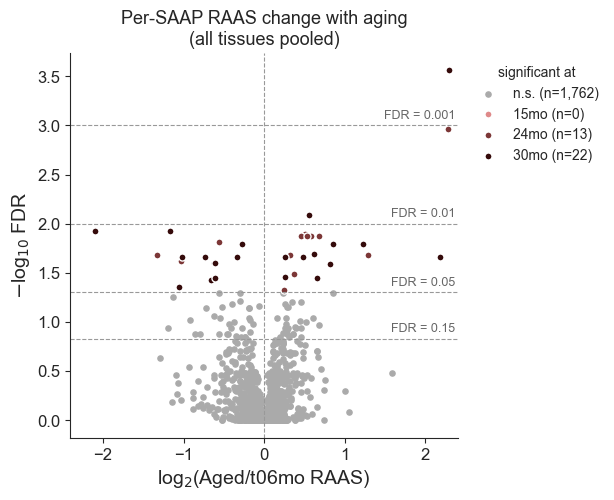


significant SAAP-changes (FDR <= 0.05) plotted by aged timepoint:
age
t15mo     0
t24mo    13
t30mo    22


In [476]:
# Volcano of per-SAAP RAAS changes with aging -- ALL aged timepoints + tissues pooled into one plot.
#      x = mean log2(Aged/Young RAAS) (cur.mean - base.mean, scaled to log2); y = -log10 of the active
#      significance metric (FDR or raw p, per the USE_FDR toggle, via sig_col()/sig_label()).
#      Non-significant SAAPs are grey; significant SAAPs (sig_col() <= sig) are colored by the aged
#      timepoint they were compared against the 6mo baseline at (15mo / 24mo / 30mo). Each (tissue x SAAP
#      x comparison) row in aging_ttest_df (cell above) is one point, so a SAAP can appear up to 3x
#      (once per aged timepoint). Older timepoints are drawn last so they sit on top.

# aging-timepoint palette (warm ramp deepening with age); grey = not significant
AGE_COLORS = {'t15mo': "#df8a8a", 't24mo': "#7c3737", 't30mo': "#350b0b"}
NS_COLOR   = '#aaaaaa'

# horizontal reference lines, drawn at -log10 of each value on the active-metric (sig_col()) axis
# SIG_LINES = [0.05, 0.01, 0.001, 0.0001, 0.00001] # pval
SIG_LINES = [0.15, 0.05, 0.01, 0.001] # FDR

def plot_aging_volcano(df, *, age_colors=AGE_COLORS, ns_color=NS_COLOR, sig_lines=SIG_LINES):
    metric = sig_col()                                       # 'FDR' or 'p_value' per USE_FDR
    d = df.dropna(subset=['mean_log2FC', metric]).copy()
    d['age'] = d['comparison'].str.split().str[0]            # 't15mo' from 't15mo vs t06mo'
    # -log10 with a floor so a metric value of 0 (numeric underflow) stays finite/on-scale
    floor = d.loc[d[metric] > 0, metric].min()
    d['neglog10'] = -np.log10(d[metric].clip(lower=floor))

    sns.set_style('ticks')
    fig, ax = plt.subplots(figsize=(5, 5))

    # non-significant background first (significance set earlier in 3c: sig_col() <= sig)
    ns = d[~d['significant']]
    ax.scatter(ns['mean_log2FC'], ns['neglog10'], s=14, color=ns_color, alpha=1,
               linewidths=1, label=f'n.s. (n={len(ns):,})', rasterized=True)
    # significant SAAPs only, colored by aged timepoint, oldest plotted last (on top)
    for age in [a for a in age_order if a in age_colors]:
        sub = d[d['significant'] & (d['age'] == age)]
        ax.scatter(sub['mean_log2FC'], sub['neglog10'], s=26, color=age_colors[age], alpha=1,
                   linewidths=1, edgecolors='white', label=f'{age[1:]} (n={len(sub):,})')

    xlim = np.nanmax(np.abs(d['mean_log2FC'])) * 1.05         # symmetric x so up/down read evenly
    ax.set_xlim(-xlim, xlim)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')

    # horizontal reference lines at the active metric (FDR or p), labeled at the right edge
    for v in sig_lines:
        y = -np.log10(v)
        ax.axhline(y, color='#999999', lw=0.8, ls='--')
        ax.annotate(f'{sig_label()} = {v:g}', (ax.get_xlim()[1], y),
                    xytext=(-2, 3), textcoords='offset points', ha='right', va='bottom',
                    fontsize=9, color='#666666')

    ax.set_xlabel('log$_2$(Aged/t06mo RAAS)', fontsize=14)
    ax.set_ylabel(f'$-$log$_{{10}}$ {sig_label()}', fontsize=14)
    ax.set_title(f'Per-SAAP RAAS change with aging\n(all tissues pooled)', fontsize=13)
    ax.tick_params('both', labelsize=12)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(title='significant at', fontsize=10, title_fontsize=10, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1))

    plt.savefig(PLOT_DIR + 'Aging_RAAS_global_volcano.pdf', bbox_inches='tight')
    plt.savefig(PLOT_DIR + 'Aging_RAAS_global_volcano.png', dpi=600, bbox_inches='tight')
    plt.show()
    return d

_volcano = plot_aging_volcano(aging_ttest_global_df)
print(f"\nsignificant SAAP-changes ({sig_label()} <= {sig}) plotted by aged timepoint:")
print(_volcano[_volcano['significant']].groupby('age').size().reindex(aged).fillna(0).astype(int).to_string())

In [477]:
# Save as Supplemental_Data_3.1.SAAP_age_related.xlsx  (+ ..._statistics.xlsx)
# A subset of SAAP shown confidently to change across aging and their statistics.
# Built from aging_ttest_df (cell "3c"): "confident changers" = SAAPs significant in >=1 aged-vs-6mo
# comparison by the active metric (sig_col() = FDR if USE_FDR else p_value, threshold = sig).

SAAP_INDEX = [*SAAP_KEYS]

# confident changers: any aged timepoint significant vs the 6mo baseline
confident_keys = (aging_ttest_global_df.loc[aging_ttest_global_df[sig_col()] <= sig, SAAP_INDEX]
                  .drop_duplicates())

# statistics table -- every aged-vs-6mo comparison for those confident SAAPs (full stats)
age_related_statistics = (aging_ttest_global_df.merge(confident_keys, on=SAAP_INDEX)
                          .sort_values(SAAP_INDEX + ['comparison'])
                          .set_index(SAAP_INDEX))

age_related_statistics.to_excel(SUPP_DIR + 'Supplemental_Data_4.2.SAAP_global_age_related_statistics.xlsx',
                                sheet_name='statistics', index=True)

# (2) SAAP-level subset -- every SAAP_quant_df row for the confident SAAPs, keeping all
# quant columns, with per-timepoint log2FC + significance appended
_fc_wide = (age_related_statistics.reset_index()
            .pivot_table(index=SAAP_INDEX, columns='comparison', values='mean_log2FC'))
_fc_wide.columns = [f'log2FC {c}' for c in _fc_wide.columns]
_sig_wide = (age_related_statistics.reset_index()
             .pivot_table(index=SAAP_INDEX, columns='comparison', values=sig_col()))
_sig_wide.columns = [f'{sig_label()} {c}' for c in _sig_wide.columns]
_stats_block = _fc_wide.join(_sig_wide).reset_index()

age_related_saaps = (SAAP_quant_df.reset_index()
                     .merge(confident_keys, on=SAAP_INDEX, how='inner')
                     .merge(_stats_block, on=SAAP_INDEX, how='left')
                     .sort_values(SAAP_INDEX + ['Sample Type', 'Replicate']))

age_related_saaps.to_excel(SUPP_DIR + 'Supplemental_Data_4.1.SAAP_global_age_related.xlsx',
                           sheet_name='SAAP_age_related', index=False)



# age_gene_list = pd.DataFrame({
#     'MTP_seq': age_related_saaps['MTP_seq'],
#     'BP_seq': age_related_saaps['BP_seq'],
#     'swap': age_related_saaps['aa_sub'],
#     'gene': age_related_saaps['Source_gene'],
#     'accession': age_related_saaps['Source_accessions'],
#     'protein': age_related_saaps['Source_protein']
# }).drop_duplicates()

# print(age_gene_list)

# age_gene_list.to_csv(SUPP_DIR + 'Data_5.SAAP_global_age_related_gene_list.tsv',sep='\t',index=False)


age_gene_list = pd.DataFrame({
    'MTP_seq': age_related_saaps['MTP_seq'],
    'BP_seq': age_related_saaps['BP_seq'],
    'swap': age_related_saaps['aa_sub'],
    'gene': age_related_saaps['Source_gene'],
    'accession': age_related_saaps['Source_accessions'],
    'protein': age_related_saaps['Source_protein']
}).drop_duplicates()

print(age_gene_list)

age_gene_list.to_csv(SUPP_DIR + 'Data_5.SAAP_global_age_related_gene_list_leading_only.tsv',sep='\t',index=False)

                    MTP_seq                  BP_seq      swap           gene  \
381             APFPSIVGRPR             AVFPSIVGRPR    V to P          Acta1   
413              DALLQEQGTK              WALLQEQGTK    W to D           Krt5   
268               DGVVEITGK               EGVVEITGK    E to D          Hspb1   
13             DIAMDGTEGLVR            TIAMDGTEGLVR    T to D        Atp5f1b   
348             DNQLHLDDALR             DTQLHLDDALR    T to N           Myh4   
45              DSYVGDELQSK             DSYVGDEAQSK  A to I/L          Actc1   
332            ELEDEVENEQKR            ELEGEVENEQKR    G to D           Myh1   
138             FNVDDTAGQEK             FNVWDTAGQEK    W to D  1700009N14Rik   
57   GGSEVQIFAPDVPQMHVIDHTK  GGAEVQIFAPDVPQMHVIDHTK    A to S          Gatd3   
106            GTSQNDPNNVVR            GTSQNDPNWVVR    W to N          Thbs1   
122            GTSQNDPNWNVR            GTSQNDPNWVVR    V to N          Thbs1   
364             INLSQVGDVLR             

## ANOVA - Is there any change with age at all?

In [478]:
# Per-SAAP one-way ANOVA of log10 RAAS across all ages (t06/t15/t24/t30). Omnibus test:
#      "does RAAS differ across age at all?" Complements the pairwise t-tests (which say WHERE).
#      Reuses iter_saaps: rep=None -> within-tissue (Dataset x SAAP); pass a pooled rep for global.
#      BH-FDR across SAAPs within the comparison, matching the t-test convention.

from scipy.stats import f_oneway

def _anova_rows(iterator):
    """Run one-way ANOVA across ages per SAAP over the given iterator (iter_saaps or iter_saaps_global)."""
    rows = []
    ages_all = [baseline] + list(aged)
    for item in iterator:
        # iter_saaps yields (tissue, keys, by_age, g); iter_saaps_global yields (keys, by_age, g)
        if len(item) == 4:
            tissue, keys, by_age, _ = item
        else:
            keys, by_age, _ = item
            tissue = 'all'
        groups = [by_age.get(a, np.empty(0)) for a in ages_all]
        groups = [grp for grp in groups if len(grp) >= min_reps]
        if len(groups) < 2:                            # need >= 2 age groups
            continue
        res = f_oneway(*groups)
        all_vals = np.concatenate(groups)
        rows.append({
            'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
            'comparison': 'age effect (one-way ANOVA)',
            'n_groups': len(groups), 'n_total': len(all_vals),
            'grand_mean_RAAS': all_vals.mean(),
            'F_stat': float(res.statistic), 'p_value': float(res.pvalue),
            'test': 'one-way ANOVA'})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')
    if not out.empty:
        out['significant'] = out[sig_col()] <= sig
    return out

aging_anova_df        = _anova_rows(iter_saaps())          # within-tissue
aging_anova_global_df = _anova_rows(iter_saaps_global())   # global (pooled across tissues)
pickle.dump(aging_anova_df,        open(OUTDIR + 'Aging_RAAS_oneway_anova.p', 'wb'))
pickle.dump(aging_anova_global_df, open(OUTDIR + 'Aging_RAAS_oneway_anova_global.p', 'wb'))

print(f"One-way ANOVA of log10 RAAS across all ages ({' / '.join([baseline] + list(aged))})")
print(f"  multiplicity = BH-FDR across SAAPs within comparison | significance = {sig_label()} <= {sig}")
print(f"  within-tissue: {len(aging_anova_df):,} (tissue x SAAP) | global: {len(aging_anova_global_df):,} SAAP groups\n")
sig_summary(aging_anova_df, 'p_value', 'comparison')

One-way ANOVA of log10 RAAS across all ages (t06mo / t15mo / t24mo / t30mo)
  multiplicity = BH-FDR across SAAPs within comparison | significance = FDR <= 0.05
  within-tissue: 755 (tissue x SAAP) | global: 599 SAAP groups

    age effect (one-way ANOVA) tested= 755 p<=0.05:  164    FDR<=0.05:   59


In [479]:
# Tukey HSD post-hoc on ANOVA-significant SAAPs: all pairwise age comparisons with Tukey's
#      family-wise correction. Tukey's p-adj already controls error across the pairwise tests
#      within a SAAP, so it is used directly (no extra BH-FDR on top).
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def tukey_posthoc(anova_df, iterator, key_cols):
    """Run Tukey HSD per ANOVA-significant SAAP. key_cols matches the ANOVA grouping."""
    sig_keys = set(map(tuple, anova_df.loc[anova_df['significant'], key_cols].values))
    ages_all = [baseline] + list(aged)
    rows = []
    for item in iterator:
        if len(item) == 4:
            tissue, keys, by_age, _ = item
            full_key = (tissue,) + tuple(keys)
        else:
            keys, by_age, _ = item
            full_key = tuple(keys)
        if full_key not in sig_keys:
            continue
        vals, labs = [], []
        for a in ages_all:
            v = by_age.get(a, np.empty(0))
            if len(v) >= min_reps:
                vals.append(v); labs += [a] * len(v)
        if len(set(labs)) < 2:
            continue
        tuk = pairwise_tukeyhsd(np.concatenate(vals), labs)
        for g1, g2, md, padj, lo, hi, rej in tuk._results_table.data[1:]:
            rows.append({
                **dict(zip(key_cols, full_key)),
                'group1': g1, 'group2': g2,
                'meandiff_RAAS': float(md), 'meandiff_log2FC': float(md) * np.log2(10),
                'p_adj': float(padj), 'ci_low': float(lo), 'ci_high': float(hi),
                'reject': bool(rej), 'direction': 'up' if md >= 0 else 'down'})
    return pd.DataFrame(rows)

aging_tukey_df        = tukey_posthoc(aging_anova_df,        iter_saaps(),        ['Dataset', *SAAP_KEYS])
aging_tukey_global_df = tukey_posthoc(aging_anova_global_df, iter_saaps_global(), list(SAAP_KEYS))
pickle.dump(aging_tukey_df,        open(OUTDIR + 'Aging_RAAS_tukey.p', 'wb'))
pickle.dump(aging_tukey_global_df, open(OUTDIR + 'Aging_RAAS_tukey_global.p', 'wb'))

print("Tukey HSD post-hoc on ANOVA-significant SAAPs (p_adj is Tukey's own family-wise correction)")
print(f"  within-tissue: {int(aging_tukey_df['reject'].sum()) if not aging_tukey_df.empty else 0:,} sig pairwise / {len(aging_tukey_df):,} tested")
print(f"  global:        {int(aging_tukey_global_df['reject'].sum()) if not aging_tukey_global_df.empty else 0:,} sig pairwise / {len(aging_tukey_global_df):,} tested")

Tukey HSD post-hoc on ANOVA-significant SAAPs (p_adj is Tukey's own family-wise correction)
  within-tissue: 185 sig pairwise / 354 tested
  global:        115 sig pairwise / 216 tested


In [480]:
print(aging_tukey_global_df)

             MTP_seq           BP_seq  aa_sub group1 group2  meandiff_RAAS  \
0    ALQPIVSEEEAAHTK  ALQPIVSEEEWAHTK  W to A  t06mo  t15mo         0.0284   
1    ALQPIVSEEEAAHTK  ALQPIVSEEEWAHTK  W to A  t06mo  t24mo         0.0854   
2    ALQPIVSEEEAAHTK  ALQPIVSEEEWAHTK  W to A  t06mo  t30mo         0.0715   
3    ALQPIVSEEEAAHTK  ALQPIVSEEEWAHTK  W to A  t15mo  t24mo         0.0569   
4    ALQPIVSEEEAAHTK  ALQPIVSEEEWAHTK  W to A  t15mo  t30mo         0.0430   
..               ...              ...     ...    ...    ...            ...   
211     WTVHLMETLLPR     WPVHLMETLLPR  P to T  t06mo  t24mo        -0.1326   
212     WTVHLMETLLPR     WPVHLMETLLPR  P to T  t06mo  t30mo        -0.1829   
213     WTVHLMETLLPR     WPVHLMETLLPR  P to T  t15mo  t24mo        -0.0408   
214     WTVHLMETLLPR     WPVHLMETLLPR  P to T  t15mo  t30mo        -0.0911   
215     WTVHLMETLLPR     WPVHLMETLLPR  P to T  t24mo  t30mo        -0.0503   

     meandiff_log2FC   p_adj  ci_low  ci_high  reject direction

In [481]:
print(aging_anova_global_df)

    Dataset                MTP_seq                 BP_seq  aa_sub  \
0       all        AAAQNIIPASTGAAK        GAAQNIIPASTGAAK  G to A   
1       all  AAATQPDGKDTPDETWAFPAR  AAATQPDGKDTPDEPWAFPAR  P to T   
2       all             AADEVDSGRR             AAWEVDSGRR  W to D   
3       all             AAFAGDDAPR             AGFAGDDAPR  G to A   
4       all             AAFQLGSTWR             AAFQLGSPWR  P to T   
..      ...                    ...                    ...     ...   
594     all           YLADASTMDHAR           YLATASTMDHAR  T to D   
595     all             YNDLGEQDFK             YNDLGEQHFK  H to D   
596     all             YNDLGEQNFK             YNDLGEQHFK  H to N   
597     all               YSLPIIPK               YSLVIIPK  V to P   
598     all            YVMGDAPDFDR            YTMGDAPDFDR  T to V   

                     comparison  n_groups  n_total  grand_mean_RAAS    F_stat  \
0    age effect (one-way ANOVA)         4       16        -3.256532  2.110706   
1    age 

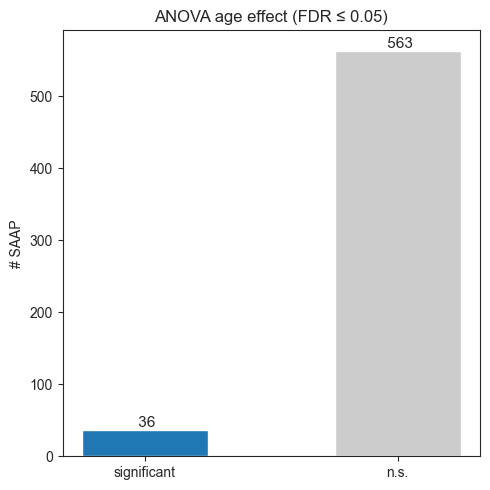

In [482]:
# Four-panel summary of per-SAAP one-way ANOVA results (aging_anova_global_df).
#   (a) significant vs non-significant SAAP counts
#   (b) top SAAPs by F-statistic
#   (c) significant SAAPs grouped by aa_sub
#   (d) -log10(FDR) for the top SAAPs
# Consumes aging_anova_global_df (one row per SAAP) and, for direction in (c),
#   aging_tukey_global_df (pairwise, signed). Style follows the project rcParams.

TOP_N = 15                                   # bars in the per-SAAP panels
df = aging_anova_global_df.copy()
fdr = sig_col()                              # 'FDR' if USE_FDR else 'p_value'

# compact SAAP label: aa_sub + short MTP hint, kept unique
def _saap_label(r):
    sub = r.get('aa_sub', '')
    mtp = str(r.get('MTP_seq', ''))
    return f"{sub} {mtp[:6]}" if mtp else str(sub)
df['saap_label'] = df.apply(_saap_label, axis=1)

fig, ax = plt.subplots(figsize=(5, 5))

n_sig    = int(df['significant'].sum())
n_nonsig = int((~df['significant']).sum())
ax.bar(['significant', 'n.s.'], [n_sig, n_nonsig],
         color=[colors[0], '#cccccc'], width=0.5)
for i, v in enumerate([n_sig, n_nonsig]):
    ax.text(i, v, f' {v:,}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('# SAAP')
ax.set_title(f'ANOVA age effect ({sig_label()} \u2264 {sig})')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'aging_anova_global_summary.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'aging_anova_global_summary.png', dpi=600, bbox_inches='tight')
plt.show()

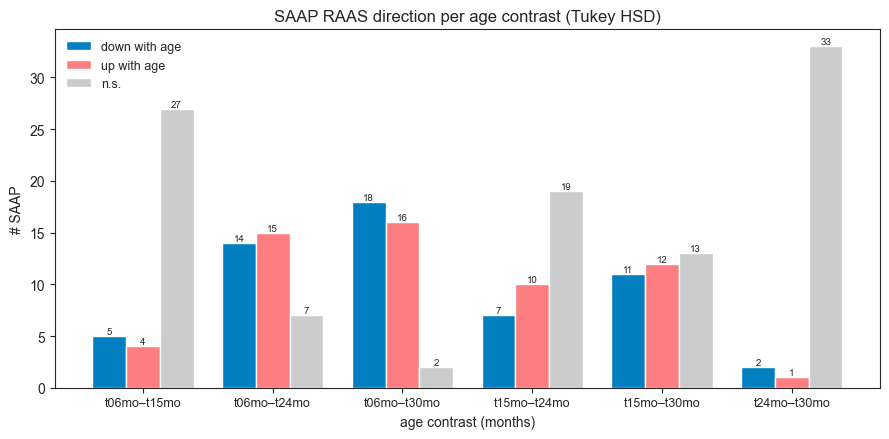

In [483]:
# Stacked counts of SAAP age-effect direction per pairwise age contrast (Tukey HSD).
#   x-axis : all 6 pairwise age contrasts (t06/t15/t24/t30)
#   stack  : significant up (pink) / significant down (blue) / non-significant (grey)
#   y      : # SAAP
# Consumes aging_tukey_global_df (one row per pairwise contrast per ANOVA-sig SAAP).
#   reject = Tukey's own family-wise-corrected significance; meandiff sign = direction.

AGE_ORDER = [baseline] + list(aged)          # canonical age ordering for labels
rank = {a: i for i, a in enumerate(AGE_ORDER)}

tk = aging_tukey_global_df.copy()

# normalize each contrast to canonical age order; flip meandiff sign if reordered
def _norm(r):
    g1, g2, md = r['group1'], r['group2'], r['meandiff_RAAS']
    if rank.get(g1, 0) > rank.get(g2, 0):    # swap so g1 is younger
        g1, g2, md = g2, g1, -md
    return pd.Series({'pair': f'{g1}\u2013{g2}', 'md': md})

tk[['pair', 'md']] = tk.apply(_norm, axis=1)

# classify each row: up / down / n.s.
def _cls(r):
    if not r['reject']:
        return 'n.s.'
    return 'up' if r['md'] >= 0 else 'down'
tk['cls'] = tk.apply(_cls, axis=1)

# order pairs by canonical (younger, older)
pair_order = sorted(tk['pair'].unique(),
                    key=lambda p: (rank[p.split('\u2013')[0]], rank[p.split('\u2013')[1]]))
ct = (tk.groupby(['pair', 'cls']).size().unstack(fill_value=0)
        .reindex(pair_order))
for c in ['down', 'up', 'n.s.']:
    if c not in ct:
        ct[c] = 0

DOWN_C, UP_C, NS_C = '#027FC1', '#FD7E81', '#cccccc'   # blue / pink / grey
cats = [('down', DOWN_C, 'down with age'),
        ('up',   UP_C,   'up with age'),
        ('n.s.', NS_C,   'n.s.')]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ct))
w = 0.26                                     # bar width; 3 bars per group
for j, (c, col, lab) in enumerate(cats):
    offs = (j - 1) * w                       # center the triplet on each tick
    ax.bar(x + offs, ct[c], width=w, color=col, label=lab)
    for i, v in enumerate(ct[c]):
        if v:
            ax.text(x[i] + offs, v, f'{int(v)}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(list(x))
ax.set_xticklabels(pair_order, rotation=0, fontsize=9)
ax.set_ylabel('# SAAP')
ax.set_xlabel('age contrast (months)')
ax.set_title('SAAP RAAS direction per age contrast (Tukey HSD)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'aging_tukey_direction_by_contrast.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'aging_tukey_direction_by_contrast.png', dpi=600, bbox_inches='tight')
plt.show()

# Spearman Correlations of RAAS with Aging

## SAAP LEVEL

In [484]:
# Per-SAAP trend of log10 RAAS vs age (t06=6 / t15=15 / t24=24 / t30=30 months). Two tests per SAAP:
#      Spearman rho (monotonic age effect; feeds FDR) and OLS (linear slope = effect size per month).
#      Each by_age[a] is a list of biological reps, so the fit stacks reps across 4 age levels.
#      Reuses iter_saaps: within-tissue (Dataset x SAAP) vs iter_saaps_global (one row per SAAP).
#      BH-FDR across SAAPs, matching the t-test/ANOVA convention.

from scipy.stats import spearmanr, linregress, wilcoxon, ttest_1samp

AGE_MONTHS = {'t06mo': 6, 't15mo': 15, 't24mo': 24, 't30mo': 30}

def make_saap_id(keys):
    return "__".join(map(str, keys))                   # SAAP identity, unique per iterator row

def _age_effect_rows_saap(iterator):
    """Per-SAAP Spearman + OLS of log10 RAAS vs age over the given iterator."""
    rows = []
    for item in iterator:
        # iter_saaps yields (tissue, keys, by_age, g); iter_saaps_global yields (keys, by_age, g)
        if len(item) == 4:
            tissue, keys, by_age, _ = item
        else:
            keys, by_age, _ = item
            tissue = 'all'
        ages, vals = [], []                            # stack reps across age levels
        for a, v in by_age.items():
            if a not in AGE_MONTHS:
                continue
            vv = [x for x in v if x is not None and np.isfinite(x)]
            ages.extend([AGE_MONTHS[a]] * len(vv))
            vals.extend(vv)
        ages, vals = np.asarray(ages, float), np.asarray(vals, float)
        if len(vals) < min_reps or len(np.unique(ages)) < 2:   # need >= 2 age levels
            continue
        rho, p_s = spearmanr(ages, vals)
        if not np.isfinite(rho):                       # zero-variance vals -> nan, skip
            continue
        lr = linregress(ages, vals)
        rows.append({
            'saap_id': make_saap_id(keys), 'Dataset': tissue,
            'aa_sub': keys[-1] if keys else None,      # annotation only, not a grouping key
            'n_points': len(vals), 'n_ages': len(np.unique(ages)),
            'spearman_rho': float(rho), 'p_value': float(p_s),
            'ols_slope_per_month': float(lr.slope),
            'ols_slope_log2FC_per_month': float(lr.slope) * np.log2(10),
            'ols_intercept': float(lr.intercept), 'ols_r': float(lr.rvalue), 'ols_p': float(lr.pvalue),
            'test': 'SAAP-level Spearman + OLS'})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = fdr_within(df, 'p_value', 'test')             # BH-FDR across SAAPs
    df['direction'] = np.where(df['spearman_rho'] >= 0, 'up', 'down')
    df['significant'] = df[sig_col()] <= sig
    return df

# Population-level claim: is the per-SAAP rho distribution shifted off 0 ("does RAAS trend with age
#      on average?"). Distinct from the per-SAAP FDR hits. Run on the global frame so each rho is
#      one independent observation. Wilcoxon (median) primary; one-sample t (mean) secondary.

def population_rho_test(df, label='global'):
    """Test whether the per-SAAP rho distribution differs from 0."""
    rho = df['spearman_rho'].dropna().values
    if not len(rho):
        return None
    w, w_p = wilcoxon(rho)
    t, t_p = ttest_1samp(rho, 0.0)
    print(f"\nPopulation rho-distribution test ({label})")
    print(f"  n SAAP       = {len(rho):,}")
    print(f"  median rho   = {np.median(rho):+.4f}   <- lead with this")
    print(f"  Wilcoxon     = W={w:.0f} p={w_p:.2e}   [primary]")
    print(f"  one-sample t = t={t:.2f} p={t_p:.2e}   [secondary]")
    print(f"  sign split   = {int((rho > 0).sum()):,} up / {int((rho < 0).sum()):,} down")
    return {'n_saap': len(rho), 'median_rho': float(np.median(rho)),
            'wilcoxon_p': float(w_p), 'ttest_p': float(t_p)}

aging_trend_df        = _age_effect_rows_saap(iter_saaps())          # within-tissue
aging_trend_global_df = _age_effect_rows_saap(iter_saaps_global())   # global (one row per SAAP)
pickle.dump(aging_trend_df,        open(OUTDIR + 'Aging_RAAS_age_trend_SAAP.p', 'wb'))
pickle.dump(aging_trend_global_df, open(OUTDIR + 'Aging_RAAS_age_trend_global_SAAP.p', 'wb'))
assert aging_trend_global_df['saap_id'].is_unique, \
    "ERROR: SAAP collapse detected — iterator is not SAAP-safe"

print("SAAP-level Spearman + OLS slope of log10 RAAS vs age (t06=6 / t15=15 / t24=24 / t30=30)")
print(f"  significance = Spearman p, BH-FDR across SAAPs | {sig_label()} <= {sig}")
print(f"  within-tissue: {len(aging_trend_df):,} SAAPs | global: {len(aging_trend_global_df):,} SAAPs\n")
sig_summary(aging_trend_global_df, 'p_value', 'test')
pop_rho_global = population_rho_test(aging_trend_global_df, 'global')

_show = ['saap_id', 'Dataset', 'n_points', 'spearman_rho', 'direction',
         'ols_slope_per_month', 'p_value', 'FDR']
_prev = aging_trend_global_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f"{v:.2e}" if pd.notna(v) else "")
_prev['spearman_rho']        = _prev['spearman_rho'].map(lambda v: f"{v:+.3f}")
_prev['ols_slope_per_month'] = _prev['ols_slope_per_month'].map(lambda v: f"{v:+.4f}")
print("\nStrongest SAAP-level monotonic trends:")
print(_prev[_show].to_string(index=False))

SAAP-level Spearman + OLS slope of log10 RAAS vs age (t06=6 / t15=15 / t24=24 / t30=30)
  significance = Spearman p, BH-FDR across SAAPs | FDR <= 0.05
  within-tissue: 755 SAAPs | global: 599 SAAPs

    SAAP-level Spearman + OLS tested= 599 p<=0.05:  109    FDR<=0.05:   54

Population rho-distribution test (global)
  n SAAP       = 599
  median rho   = +0.0000   <- lead with this
  Wilcoxon     = W=85865 p=6.48e-01   [primary]
  one-sample t = t=0.37 p=7.08e-01   [secondary]
  sign split   = 296 up / 296 down

Strongest SAAP-level monotonic trends:
                                     saap_id Dataset  n_points spearman_rho direction ols_slope_per_month  p_value      FDR
              LILPGLMSSR__LILPGLISSR__I to M     all        16       -0.958      down             -0.0254 5.52e-09 3.30e-06
              NPEGTWSVEK__NEEGTWSVEK__E to P     all        16       +0.934        up             +0.0260 1.26e-07 3.77e-05
            APFPSIVGRPR__AVFPSIVGRPR__V to P     all        16       +0.9

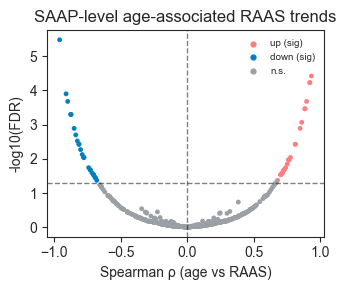

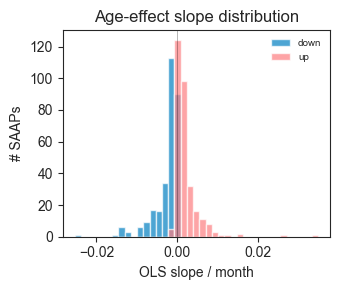

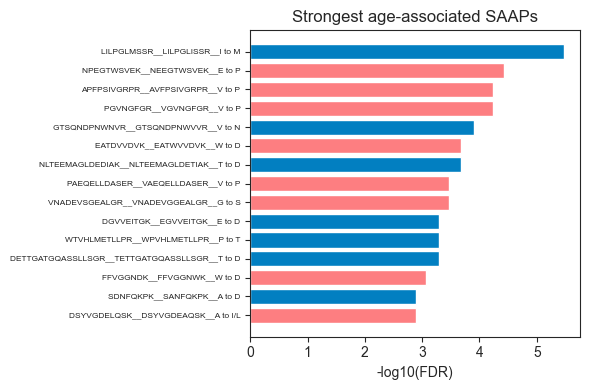

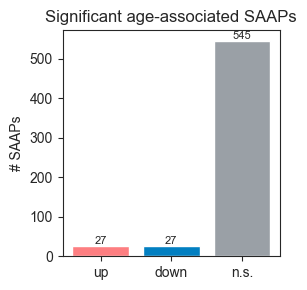

In [485]:
# Standalone figures for the SAAP-level age-trend results (global frame). Each writes its own
#      PDF + PNG. Volcano and ranked-rho use the Spearman test (the FDR source); slope dist and
#      top-hits use the OLS effect size. The ranked-rho panel carries the population-level claim:
#      is the per-SAAP rho distribution shifted off 0 (median + Wilcoxon).

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

C_DOWN, C_MID, C_UP, C_NS = '#027FC1', '#F8D7A7', '#FD7E81', '#9aa0a6'   # down / neutral / up / n.s.

df = aging_trend_global_df.dropna(subset=['spearman_rho', 'FDR']).copy()

def _neglog(s):
    return -np.log10(np.clip(s, 1e-300, None))


# Volcano: Spearman rho vs -log10(FDR), colored by significance x direction.
col = np.where(~df['significant'], C_NS,
               np.where(df['direction'] == 'up', C_UP, C_DOWN))
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.scatter(df['spearman_rho'], _neglog(df['FDR']), s=12, c=col, linewidth=0)
ax.axhline(-np.log10(sig), ls='--', c='k', lw=1, alpha=.5)   # FDR threshold
ax.axvline(0, ls='--', c='k', lw=1, alpha=.5)
for c, lab in [(C_UP, 'up (sig)'), (C_DOWN, 'down (sig)'), (C_NS, 'n.s.')]:
    ax.scatter([], [], c=c, s=12, label=lab)
ax.legend(frameon=False, fontsize=7, loc='upper right')
ax.set_xlabel('Spearman ρ (age vs RAAS)')
ax.set_ylabel('-log10(FDR)')
ax.set_title('SAAP-level age-associated RAAS trends')
fig.tight_layout()
fig.savefig(PLOT_DIR + 'SAAP_age_volcano.pdf', bbox_inches='tight')
fig.savefig(PLOT_DIR + 'SAAP_age_volcano.png', dpi=600, bbox_inches='tight')
plt.show()


# OLS slope distribution, split by direction.
sl = df['ols_slope_per_month']
b = np.linspace(sl.min(), sl.max(), 40)
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.hist(sl[df['direction'] == 'down'], bins=b, color=C_DOWN, alpha=.7, label='down')
ax.hist(sl[df['direction'] == 'up'], bins=b, color=C_UP, alpha=.7, label='up')
ax.axvline(0, c='k', lw=.5, alpha=.4)
ax.legend(frameon=False, fontsize=7)
ax.set_xlabel('OLS slope / month')
ax.set_ylabel('# SAAPs')
ax.set_title('Age-effect slope distribution')
fig.tight_layout()
fig.savefig(PLOT_DIR + 'SAAP_age_slope_dist.pdf', bbox_inches='tight')
fig.savefig(PLOT_DIR + 'SAAP_age_slope_dist.png', dpi=600, bbox_inches='tight')
plt.show()


# Top 15 SAAPs by FDR, bar colored by direction.
t = df.sort_values(sig_col()).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(np.arange(len(t)), _neglog(t['FDR']),
        color=np.where(t['direction'] == 'up', C_UP, C_DOWN))
ax.set_yticks(np.arange(len(t)))
ax.set_yticklabels(t['saap_id'], fontsize=6)
ax.set_xlabel('-log10(FDR)')
ax.set_title('Strongest age-associated SAAPs')
fig.tight_layout()
fig.savefig(PLOT_DIR + 'SAAP_age_top_hits.pdf', bbox_inches='tight')
fig.savefig(PLOT_DIR + 'SAAP_age_top_hits.png', dpi=600, bbox_inches='tight')
plt.show()


# Significant SAAP counts: up / down / n.s.
nu = int((df['significant'] & (df['direction'] == 'up')).sum())
nd = int((df['significant'] & (df['direction'] == 'down')).sum())
ns = int((~df['significant']).sum())
fig, ax = plt.subplots(figsize=(3, 3))
ax.bar(['up', 'down', 'n.s.'], [nu, nd, ns], color=[C_UP, C_DOWN, C_NS])
for i, v in enumerate([nu, nd, ns]):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
ax.set_ylabel('# SAAPs')
ax.set_title('Significant age-associated SAAPs')
fig.tight_layout()
fig.savefig(PLOT_DIR + 'SAAP_age_sig_counts.pdf', bbox_inches='tight')
fig.savefig(PLOT_DIR + 'SAAP_age_sig_counts.png', dpi=600, bbox_inches='tight')
plt.show()


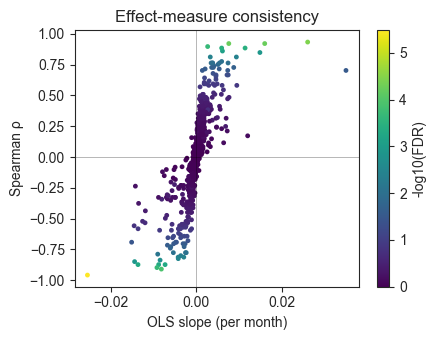

In [486]:

# ========================================================================
# Consistency check: OLS slope vs Spearman rho, colored by -log10(FDR).
# Diagnostic — confirms the two effect measures agree (should correlate).
# ========================================================================

df = aging_trend_global_df.dropna(
    subset=['spearman_rho', 'ols_slope_per_month', 'FDR']).copy()
df['neglogFDR'] = -np.log10(df['FDR'])

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sc = ax.scatter(df['ols_slope_per_month'], df['spearman_rho'],
                c=df['neglogFDR'], cmap='viridis', s=12, linewidth=0)
ax.axhline(0, color='k', lw=.5, alpha=.4)
ax.axvline(0, color='k', lw=.5, alpha=.4)
ax.set_xlabel("OLS slope (per month)")
ax.set_ylabel("Spearman ρ")
ax.set_title("Effect-measure consistency")
fig.colorbar(sc, ax=ax, label="-log10(FDR)")   # colorbar, not a discrete legend
plt.tight_layout()
plt.savefig(PLOT_DIR + "SAAP_slope_vs_rho.pdf", bbox_inches="tight")
plt.savefig(PLOT_DIR + "SAAP_slope_vs_rho.png", dpi=600, bbox_inches="tight")

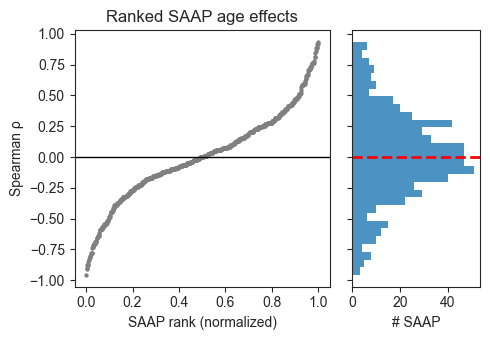

In [487]:
df=aging_trend_global_df.sort_values("spearman_rho").reset_index(drop=True)

fig,ax=plt.subplots(1,2,figsize=(5,3.5),gridspec_kw={"width_ratios":[2,1]},sharey=True)
ax0,ax1=ax

x=np.linspace(0,1,len(df),endpoint=True)
ax0.scatter(x,df["spearman_rho"],s=10,color="gray",linewidth=0)
ax0.axhline(0,color="black",linewidth=1)
ax0.set_xlabel("SAAP rank (normalized)")
ax0.set_ylabel("Spearman ρ")
ax0.set_title("Ranked SAAP age effects")

sns.histplot(y=df["spearman_rho"],bins=30,kde=False,ax=ax1,color=colors[0],alpha=0.8,linewidth=0)
ax1.axhline(0,color="red",linewidth=2,linestyle="--")
ax1.set_xlabel("# SAAP")
ax1.set_ylabel("")
# ax1.set_title("Spearman ρ Distribution")

plt.tight_layout()
plt.savefig(PLOT_DIR+"SAAP_age_ranked_rho_with_dist.pdf",bbox_inches="tight")
plt.savefig(PLOT_DIR+"SAAP_age_ranked_rho_with_dist.png",dpi=600,bbox_inches="tight")

In [488]:
print(aging_trend_global_df)

                                               saap_id Dataset  aa_sub  \
0             AAAQNIIPASTGAAK__GAAQNIIPASTGAAK__G to A     all  G to A   
1    AAATQPDGKDTPDETWAFPAR__AAATQPDGKDTPDEPWAFPAR__...     all  P to T   
2                       AADEVDSGRR__AAWEVDSGRR__W to D     all  W to D   
3                       AAFAGDDAPR__AGFAGDDAPR__G to A     all  G to A   
4                       AAFQLGSTWR__AAFQLGSPWR__P to T     all  P to T   
..                                                 ...     ...     ...   
594                 YLADASTMDHAR__YLATASTMDHAR__T to D     all  T to D   
595                     YNDLGEQDFK__YNDLGEQHFK__H to D     all  H to D   
596                     YNDLGEQNFK__YNDLGEQHFK__H to N     all  H to N   
597                         YSLPIIPK__YSLVIIPK__V to P     all  V to P   
598                   YVMGDAPDFDR__YTMGDAPDFDR__T to V     all  T to V   

     n_points  n_ages  spearman_rho   p_value  ols_slope_per_month  \
0          16       4      0.278916  0.29

## AA SUB LEVEL

In [489]:
# Per-SAAP monotonic age effect on log10 RAAS: Spearman correlation + OLS slope, vs numeric age.
#      Spearman tests MONOTONIC trend without assuming linearity, and its p-value is reliable
#      theoretically (no bootstrap needed). OLS adds an interpretable slope (RAAS change per month).
#      Both use every replicate's RAAS paired with its age. Within-tissue (iter_saaps) and global
#      (iter_saaps_global). BH-FDR across SAAPs within comparison, matching the t-test/ANOVA convention.
#
# AGE_MONTHS maps each 'Sample Type' to its numeric age. Set to match your timepoints.

from scipy.stats import linregress

AGE_MONTHS = {'t06mo': 6, 't15mo': 15, 't24mo': 24, 't30mo': 30}

def _age_effect_rows(iterator, age_col='Sample Type'):
    """Spearman + OLS of RAAS vs numeric age, per SAAP, over the given iterator."""
    rows = []
    for item in iterator:
        if len(item) == 4:                       # iter_saaps -> (tissue, keys, by_age, g)
            tissue, keys, by_age, _ = item
        else:                                    # iter_saaps_global -> (keys, by_age, g)
            keys, by_age, _ = item
            tissue = 'all'
        # build paired (age, RAAS) vectors from all replicates across ages
        ages, vals = [], []
        for a, v in by_age.items():
            if a not in AGE_MONTHS:
                continue
            ages.extend([AGE_MONTHS[a]] * len(v))
            vals.extend(v)
        ages, vals = np.asarray(ages, float), np.asarray(vals, float)
        # need >= min_reps points and >= 2 distinct ages for a correlation/slope
        if len(vals) < min_reps or len(set(ages)) < 2:
            continue
        rho, p_s = spearmanr(ages, vals)
        lr = linregress(ages, vals)              # OLS slope, intercept, r, p, stderr
        rows.append({
            'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
            'comparison': 'age trend (Spearman/OLS)',
            'n_points': len(vals), 'n_ages': len(set(ages)),
            'spearman_rho': float(rho), 'p_value': float(p_s),   # Spearman p = the significance metric
            'ols_slope_per_month': float(lr.slope),
            'ols_slope_log2FC_per_month': float(lr.slope) * np.log2(10),  # RAAS is already log10
            'ols_intercept': float(lr.intercept), 'ols_r': float(lr.rvalue), 'ols_p': float(lr.pvalue),
            'test': 'Spearman + OLS'})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')   # BH-FDR across SAAPs (on Spearman p)
    if not out.empty:
        out['direction'] = np.where(out['spearman_rho'] >= 0, 'up', 'down')
        out['significant'] = out[sig_col()] <= sig
    return out

aging_trend_df        = _age_effect_rows(iter_saaps())          # within-tissue
aging_trend_global_df = _age_effect_rows(iter_saaps_global())   # global (pooled across tissues)
pickle.dump(aging_trend_df,        open(OUTDIR + 'Aging_RAAS_age_trend.p', 'wb'))
pickle.dump(aging_trend_global_df, open(OUTDIR + 'Aging_RAAS_age_trend_global.p', 'wb'))

print(f"Spearman correlation + OLS slope of log10 RAAS vs age ({' / '.join(f'{a}={m}' for a,m in AGE_MONTHS.items())})")
print(f"  significance = Spearman p, BH-FDR across SAAPs within comparison | {sig_label()} <= {sig}")
print(f"  within-tissue: {len(aging_trend_df):,} (tissue x SAAP) | global: {len(aging_trend_global_df):,} SAAP groups\n")
sig_summary(aging_trend_global_df, 'p_value', 'comparison')

# preview: strongest monotonic trends first
_show = ['aa_sub', 'n_points', 'spearman_rho', 'direction', 'ols_slope_per_month', 'p_value', 'FDR']
_prev = aging_trend_global_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f'{v:.2e}' if pd.notna(v) else '')
_prev['spearman_rho'] = _prev['spearman_rho'].map(lambda v: f'{v:+.3f}')
_prev['ols_slope_per_month'] = _prev['ols_slope_per_month'].map(lambda v: f'{v:+.4f}')
print(f"\nstrongest monotonic trends by {sig_label()}:")
print(_prev[_show].to_string(index=False))

Spearman correlation + OLS slope of log10 RAAS vs age (t06mo=6 / t15mo=15 / t24mo=24 / t30mo=30)
  significance = Spearman p, BH-FDR across SAAPs within comparison | FDR <= 0.05
  within-tissue: 755 (tissue x SAAP) | global: 599 SAAP groups

    age trend (Spearman/OLS) tested= 599 p<=0.05:  109    FDR<=0.05:   54

strongest monotonic trends by FDR:
  aa_sub  n_points spearman_rho direction ols_slope_per_month  p_value      FDR
  I to M        16       -0.958      down             -0.0254 5.52e-09 3.30e-06
  E to P        16       +0.934        up             +0.0260 1.26e-07 3.77e-05
  V to P        16       +0.922        up             +0.0160 3.95e-07 5.91e-05
  V to P        16       +0.922        up             +0.0076 3.95e-07 5.91e-05
  V to N        16       -0.910      down             -0.0082 1.05e-06 1.25e-04
  W to D        16       +0.897        up             +0.0027 2.44e-06 2.09e-04
  T to D        16       -0.897      down             -0.0092 2.44e-06 2.09e-04
  V to P

In [490]:
aging_trend_global_df.head()[SAAP_KEYS].head()

,MTP_seq,BP_seq,aa_sub
0,AAAQNIIPASTGAAK,GAAQNIIPASTGAAK,G to A
1,AAATQPDGKDTPDETWAFPAR,AAATQPDGKDTPDEPWAFPAR,P to T
2,AADEVDSGRR,AAWEVDSGRR,W to D
3,AAFAGDDAPR,AGFAGDDAPR,G to A
4,AAFQLGSTWR,AAFQLGSPWR,P to T


# Relative RAAS computed for shared SAAP between 2 mouse samples

In [491]:
# Create a matrix with median  of relative RAAS computed for shared peptides between each pair of patients. Or read in below

all_ds_matrices = {}
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))
ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)

for sample1 in set_samples:
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]

    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        row_shared_raas_ratios = []
        col_shared_raas_ratios = []
        
        # for each SAAP shared between 2 patients, compute relative RAAS on log2 scale
        for sb, saap_bp in enumerate(shared_saap_bp):
            saap = saap_bp.split(':')[0]
            bp = saap_bp.split(':')[1]
            raas1 = sample1_df.loc[(sample1_df['MTP_seq']==saap) & (sample1_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            raas2 = sample2_df.loc[(sample2_df['MTP_seq']==saap) & (sample2_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            if ~np.isnan(raas1) and ~np.isnan(raas2) and ~np.isinf(raas1) and ~np.isinf(raas2):
                raas_ratio = raas1 - raas2
                raas_ratio = np.log2(10**raas_ratio)
                col_raas_ratio = raas2 - raas1
                col_raas_ratio = np.log2(10**col_raas_ratio)
                row_shared_raas_ratios.append(raas_ratio)
                col_shared_raas_ratios.append(col_raas_ratio)
        ds_matrix_rowcol.loc[sample1, sample2] = np.nanmedian(row_shared_raas_ratios)
        ds_matrix_rowcol.loc[sample2, sample1] = np.nanmedian(col_shared_raas_ratios)

all_ds_matrices['All_data'] = {'Row_col':ds_matrix_rowcol}

# Add N SAAP per comparison to all_data matrix
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))

ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)
for i,sample1 in enumerate(set_samples):
    if i%100==0:
        print(i)
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]
    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        ds_matrix_rowcol.loc[sample1, sample2] = len(shared_saap_bp)
        ds_matrix_rowcol.loc[sample2, sample1] = len(shared_saap_bp)

all_ds_matrices['All_data']['N_shared_saap'] = ds_matrix_rowcol

pickle.dump(all_ds_matrices, open(OUTDIR+'All_pairwise_sample_RAAS_ratio_matrices_log2.p', 'wb'))

0
100


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_59056/2476219696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)


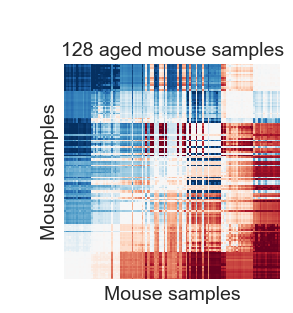

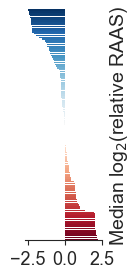

In [492]:
# plot heatmap sorted by row/col median 
ds = 'All_data'
all_ds_matrices = pickle.load(open(OUTDIR+'All_pairwise_sample_RAAS_ratio_matrices_log2.p', 'rb'))

ds_matrix = all_ds_matrices[ds]['Row_col'].astype(float)
medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in ds_matrix.iterrows()]
srt_idx = np.argsort(medians)
col_medians = [np.median([x for x in ds_matrix[col].to_list() if ~np.isnan(x)]) for col in ds_matrix.columns]
col_srt_idx = np.argsort(col_medians)
plot_matrix = ds_matrix.iloc[srt_idx, col_srt_idx]


c = sns.clustermap(plot_matrix, row_cluster=False, col_cluster=False, cmap='RdBu_r', center=0, robust=True, 
                   yticklabels=False, xticklabels=False, figsize=(3,3))#, cbar_kws={'ticklocation':'left'})
c.ax_cbar.set_visible(False)
c.ax_heatmap.set_xlabel('Mouse samples', fontsize=14)
c.ax_heatmap.set_ylabel('Mouse samples', fontsize=14)
c.ax_heatmap.yaxis.set_label_position('left')
c.ax_heatmap.set_title('128 aged mouse samples', fontsize=14)

c.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_sorted_rowcol_log2_nocbar.pdf', bbox_inches='tight')
c.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_sorted_rowcol_log2_nocbar.png', dpi=600, bbox_inches='tight')

medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in plot_matrix.iterrows()]

# barplot of patient medians
srt_medians = [medians[i] for i in srt_idx]
str_srt_idx = [str(x) for x in srt_idx]
plot_df = pd.DataFrame(zip(str_srt_idx, srt_medians), columns=['Index','Median log$_{10}$(RAAS) ratio'])
plot_df.sort_values('Median log$_{10}$(RAAS) ratio', inplace=True)

sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(1,3))
sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)
ax.set_ylabel(None)
ax.set_yticks([]);
ax.tick_params('x', labelsize=13)
plt.ylabel('Median log$_{2}$(relative RAAS)', fontsize=14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([-2.5, 0, 2.5]);
ax.yaxis.set_label_position('right')

plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.png',dpi=600, bbox_inches='tight')

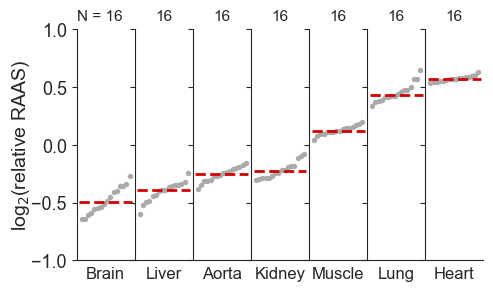

In [493]:
# Weighted means of relative RAAS for each patient in each dataset
def weighted_mean(vals, ns):
    """mean weighted by the number of shared SAAP"""
    m = (~np.isnan(vals)) & (~np.isnan(ns)) & (ns > 0)
    if np.sum(m) == 0:
        return np.nan
    return np.sum(vals[m]*ns[m]) / np.sum(ns[m])

all_ds_matrices = pickle.load(open(OUTDIR+'All_Pairwise_sample_RAAS_ratio_matrices_log2.p', 'rb'))

# matrices are nested under 'All_data' (top-level key), not at the root
block = all_ds_matrices['All_data']
all_ds_matrix   = block['Row_col'].astype(float)
all_ds_n_matrix = block['N_shared_saap'].astype(float)

# unit_dataset maps each sample ID -> tissue. It isn't stored in the pickle, so derive it
# from the index labels: '<tissue>_rep<k>_t<age>mo' -> tissue is the token before the first '_'.
unit_dataset = pd.Series(
    {s: s.split('_')[0].capitalize() for s in all_ds_matrix.index},
    name='unit_dataset')

plot_datasets = datasets[:-1]
sns.set_style('ticks')
fig, axes = plt.subplots(1, len(plot_datasets), figsize=(0.75*len(plot_datasets), 3), sharey=True)
plt.subplots_adjust(wspace=0)
sns.despine()

# get medians for sorting datasets in plot
medians = []
for i, ds in enumerate(datasets[:-1]):
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix  = all_ds_n_matrix.loc[ds_samples]
    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r, row in n_matrix.iterrows()]
    vals = [x for x in weighted_means if ~np.isnan(x)]
    medians.append(np.median(vals))
srt_idx = np.argsort(medians)
ds_sorted = [datasets[:-1][i] for i in srt_idx]

# plot weighted means
for i, ds in enumerate(ds_sorted):
    ax = axes[i]
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix  = all_ds_n_matrix.loc[ds_samples]

    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r, row in n_matrix.iterrows()]
    vals = weighted_means
    srt_idx = np.argsort(vals)
    srt_vals = [vals[s] for s in srt_idx]
    plot_df = pd.DataFrame(zip(list(range(len(vals))), srt_vals), columns=['Rank', 'RAAS ratio'])

    sns.scatterplot(data=plot_df, y='RAAS ratio', x='Rank', ax=ax, linewidth=0, s=15, color='#aaaaaa')
    ax.set_xlabel(ds, fontsize=12)
    ax.set_xticks([])
    n = len(srt_vals)
    if i == 0:
        ax.annotate('N = '+str(int(np.round(n, 0))), xy=(0.8, 1.04), xycoords='axes fraction', ha='right', fontsize=11)
    else:
        ax.annotate(str(int(np.round(n, 0))), xy=(0.5, 1.04), xycoords='axes fraction', ha='center', fontsize=11)
    median = np.median([x for x in vals if ~np.isnan(x)])
    ax.plot(ax.get_xlim(), (median, median), color='#d40000', linestyle='--', linewidth=2)

axes[0].set_yticks([-1, -0.5, 0, 0.5, 1])
axes[0].tick_params('y', labelsize=13)
axes[0].set_ylabel('log$_{2}$(relative RAAS)', fontsize=14, labelpad=-0.5)

plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.png', dpi=600, bbox_inches='tight')